# ftir_31 — every deck figure, remade in one executed notebook

## tl;dr

Every figure in the 12–13 Aug briefing decks is regenerated in this one executed
notebook: the by_protocol set from committed ftir_21/22/23 tables, the deck-root set
(filtering strip, matrix, AIRSpec explainers) from build_deck_figures, and the
implied-MAC bridge, deployed crossplot, seasonal corrected spectra, peak-center panel
and Adama/ETBI context rebuilt directly from committed tables with the deck's headline
numbers asserted (median implied MAC 11.96 / Addis-like 10.05 at n = 6,503; deployed
1.90x − 4.17 with the intercept identical at MAC 6; ETAD median Fabs 47.1 vs ETBI 26.9).
The only deck images with no repo generator are the July-17 charcoal PDF extracts.

## Context & Methods

The 13 Aug 2026 briefing decks (Ann 12 Aug, Satoshi 13 Aug) embed figures whose
generators are scattered across `build_deck_figures.py`, `build_protocol_variants.py`
and the ftir_12/16/17 notebooks. This notebook regenerates **every deck figure in one
place**, inline, so each image in the decks has a single executed provenance record.

Regeneration strategy, per figure family:

- **by_protocol set** (setup matrix, six-setup crossplots, residual-vs-D², MAC slope
  pivot, selection curves, intercept ladder, bootstrap, cohort sweep — both protocols):
  re-run `build_protocol_variants.main()`, which reads only committed ftir_21/22/23
  tables.
- **Deck-root set** (OC/EC filtering strip, combined setup matrix, the three AIRSpec
  explainer slides, intercept ladder): re-run the `build_deck_figures.py` builders
  (Drive `local_db` for the pool OC/EC; the cached explainer baselines for AIRSpec).
- **Implied-MAC bridge, deployed crossplot, seasonal spectra**: rebuilt here directly
  from the committed per-filter tables (`improve_implied_mac_bridge.csv`, phase-2
  `addis_calibration_predictions.csv`) and the local corrected-spectra cache, with the
  headline numbers asserted.
- **Peak-center and Adama/ETBI context**: rebuilt from committed stats tables plus the
  SPARTAN HIPS export; the per-filter peak-center *histogram* remains ftir_12's output
  (regenerate with `build_notebooks.py 12`) — here its committed group stats are drawn
  as a dot-and-IQR panel, stats-faithful to the deck claim.

The July-17 charcoal panels used in the Ann deck's appendix are page extracts from an
external PDF deck, not repo figures — they have no notebook to remake them in and are
listed in the manifest as such.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

sys.path.insert(0, "scripts")
sys.path.insert(0, str(Path("..") / "ftir_hips_chem" / "scripts"))

OUT = Path("output/plots/ftir31")
OUT.mkdir(parents=True, exist_ok=True)
DECK = Path("output/plots/deck")

GREY, BLUE, PURPLE, ACCENT = "#8F8C84", "#2C6E9E", "#7A4FA3", "#B23327"

def show(path, title):
    print(f"[remade] {title}: {path}")
    display(Image(filename=str(path)))

### 1. The by_protocol figure set — committed tables only

`build_protocol_variants.main()` rewrites both protocol folders (nine figures each)
from ftir_21/22/23 committed tables. The five figures the Satoshi deck uses are shown
inline; the calibration-app folder is rebuilt in the same call.

wrote 18 figures under output/plots/deck/by_protocol/
  calibration_app/
     bootstrap_intercept_ci.png
     calibration_setup_matrix.png
     cohort_size_sweep.png
     component_selection.png
     crossplots_all_setups.png
     intercept_slope_ladder.png
     mac_effect_all_setups.png
     mac_slope_pivot.png
     residual_vs_d2.png
  site_held_out/
     bootstrap_intercept_ci.png
     calibration_setup_matrix.png
     cohort_size_sweep.png
     component_selection.png
     crossplots_all_setups.png
     intercept_slope_ladder.png
     mac_effect_all_setups.png
     mac_slope_pivot.png
     residual_vs_d2.png
[remade] setup matrix (site-held-out): output/plots/deck/by_protocol/site_held_out/calibration_setup_matrix.png


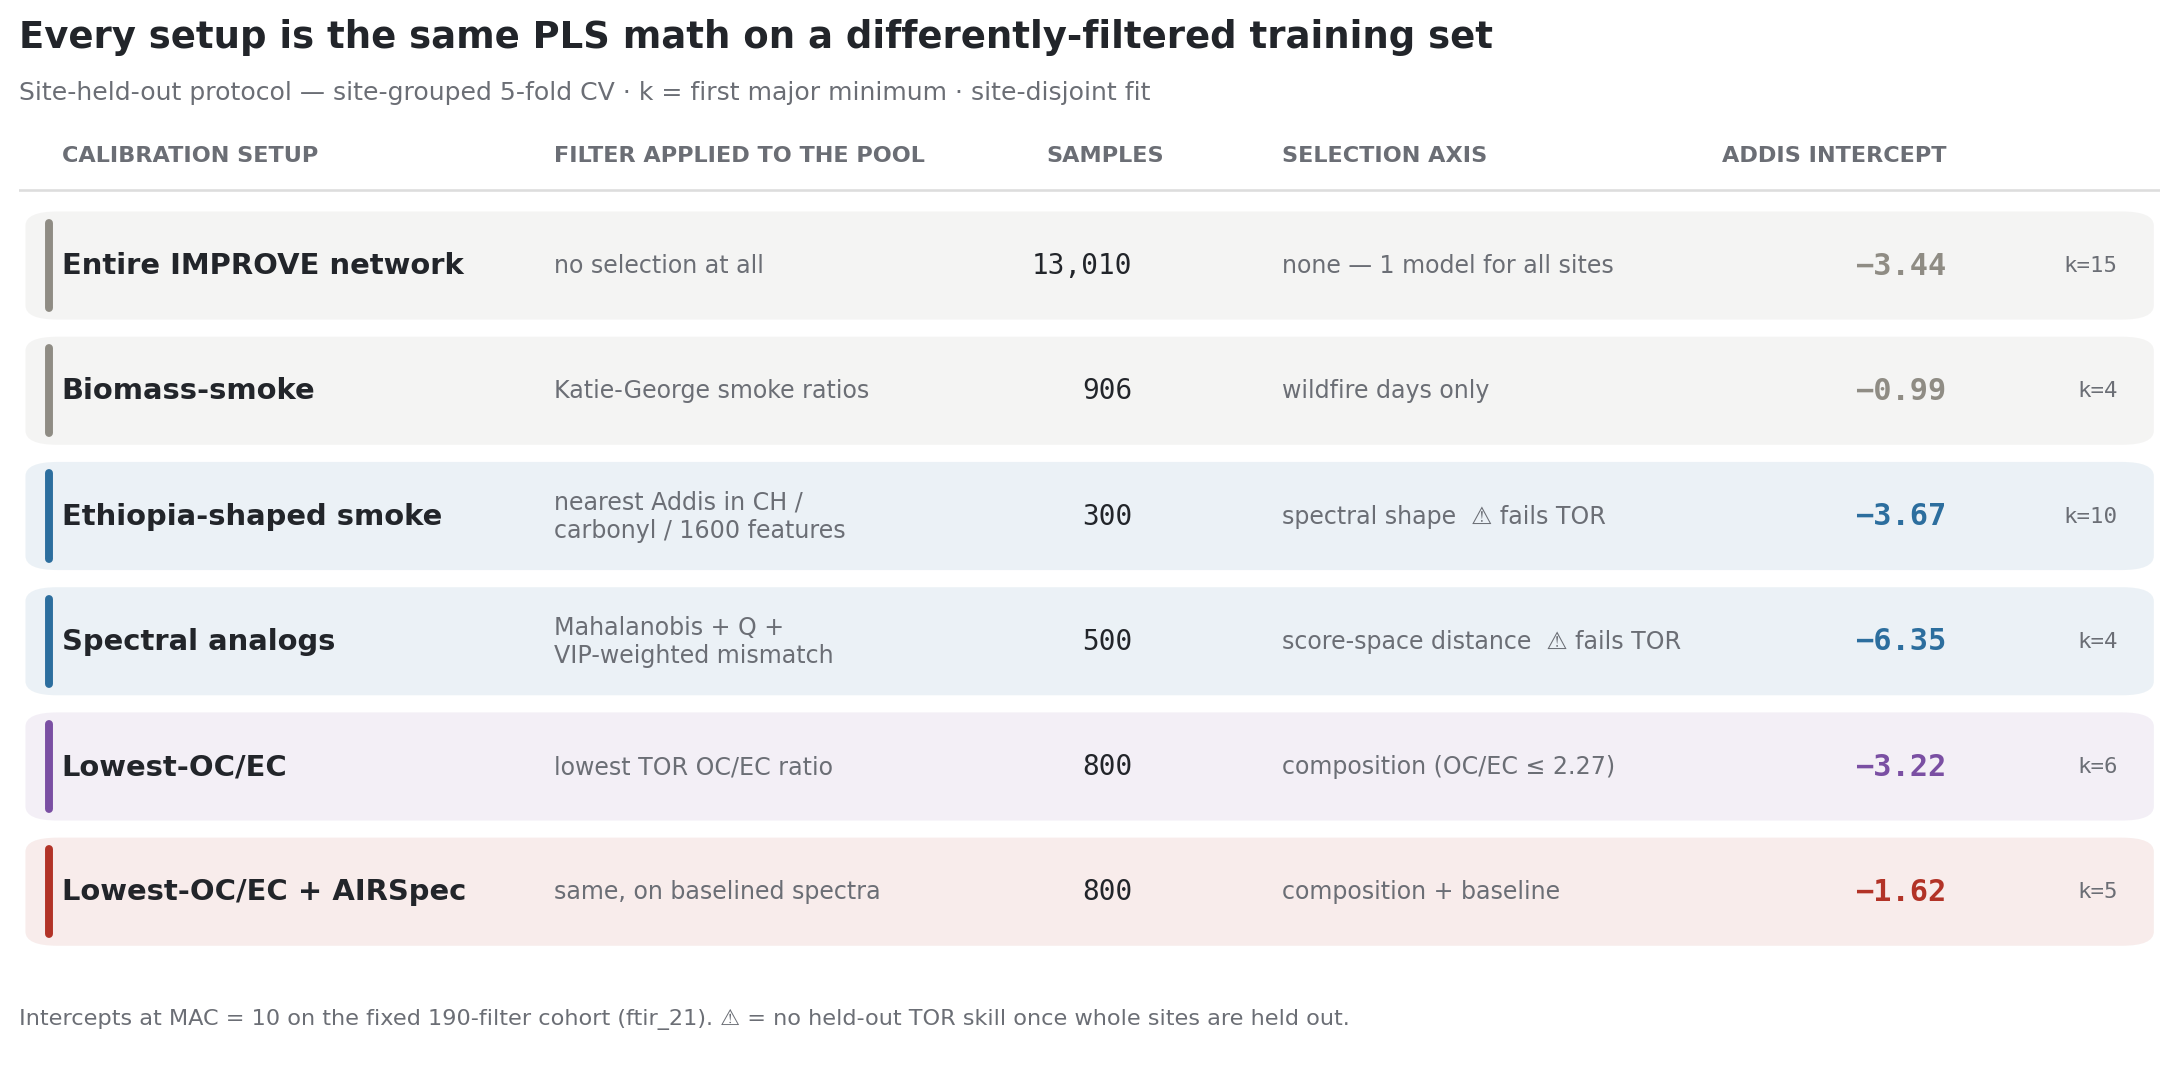

[remade] six-setup crossplots: output/plots/deck/by_protocol/site_held_out/crossplots_all_setups.png


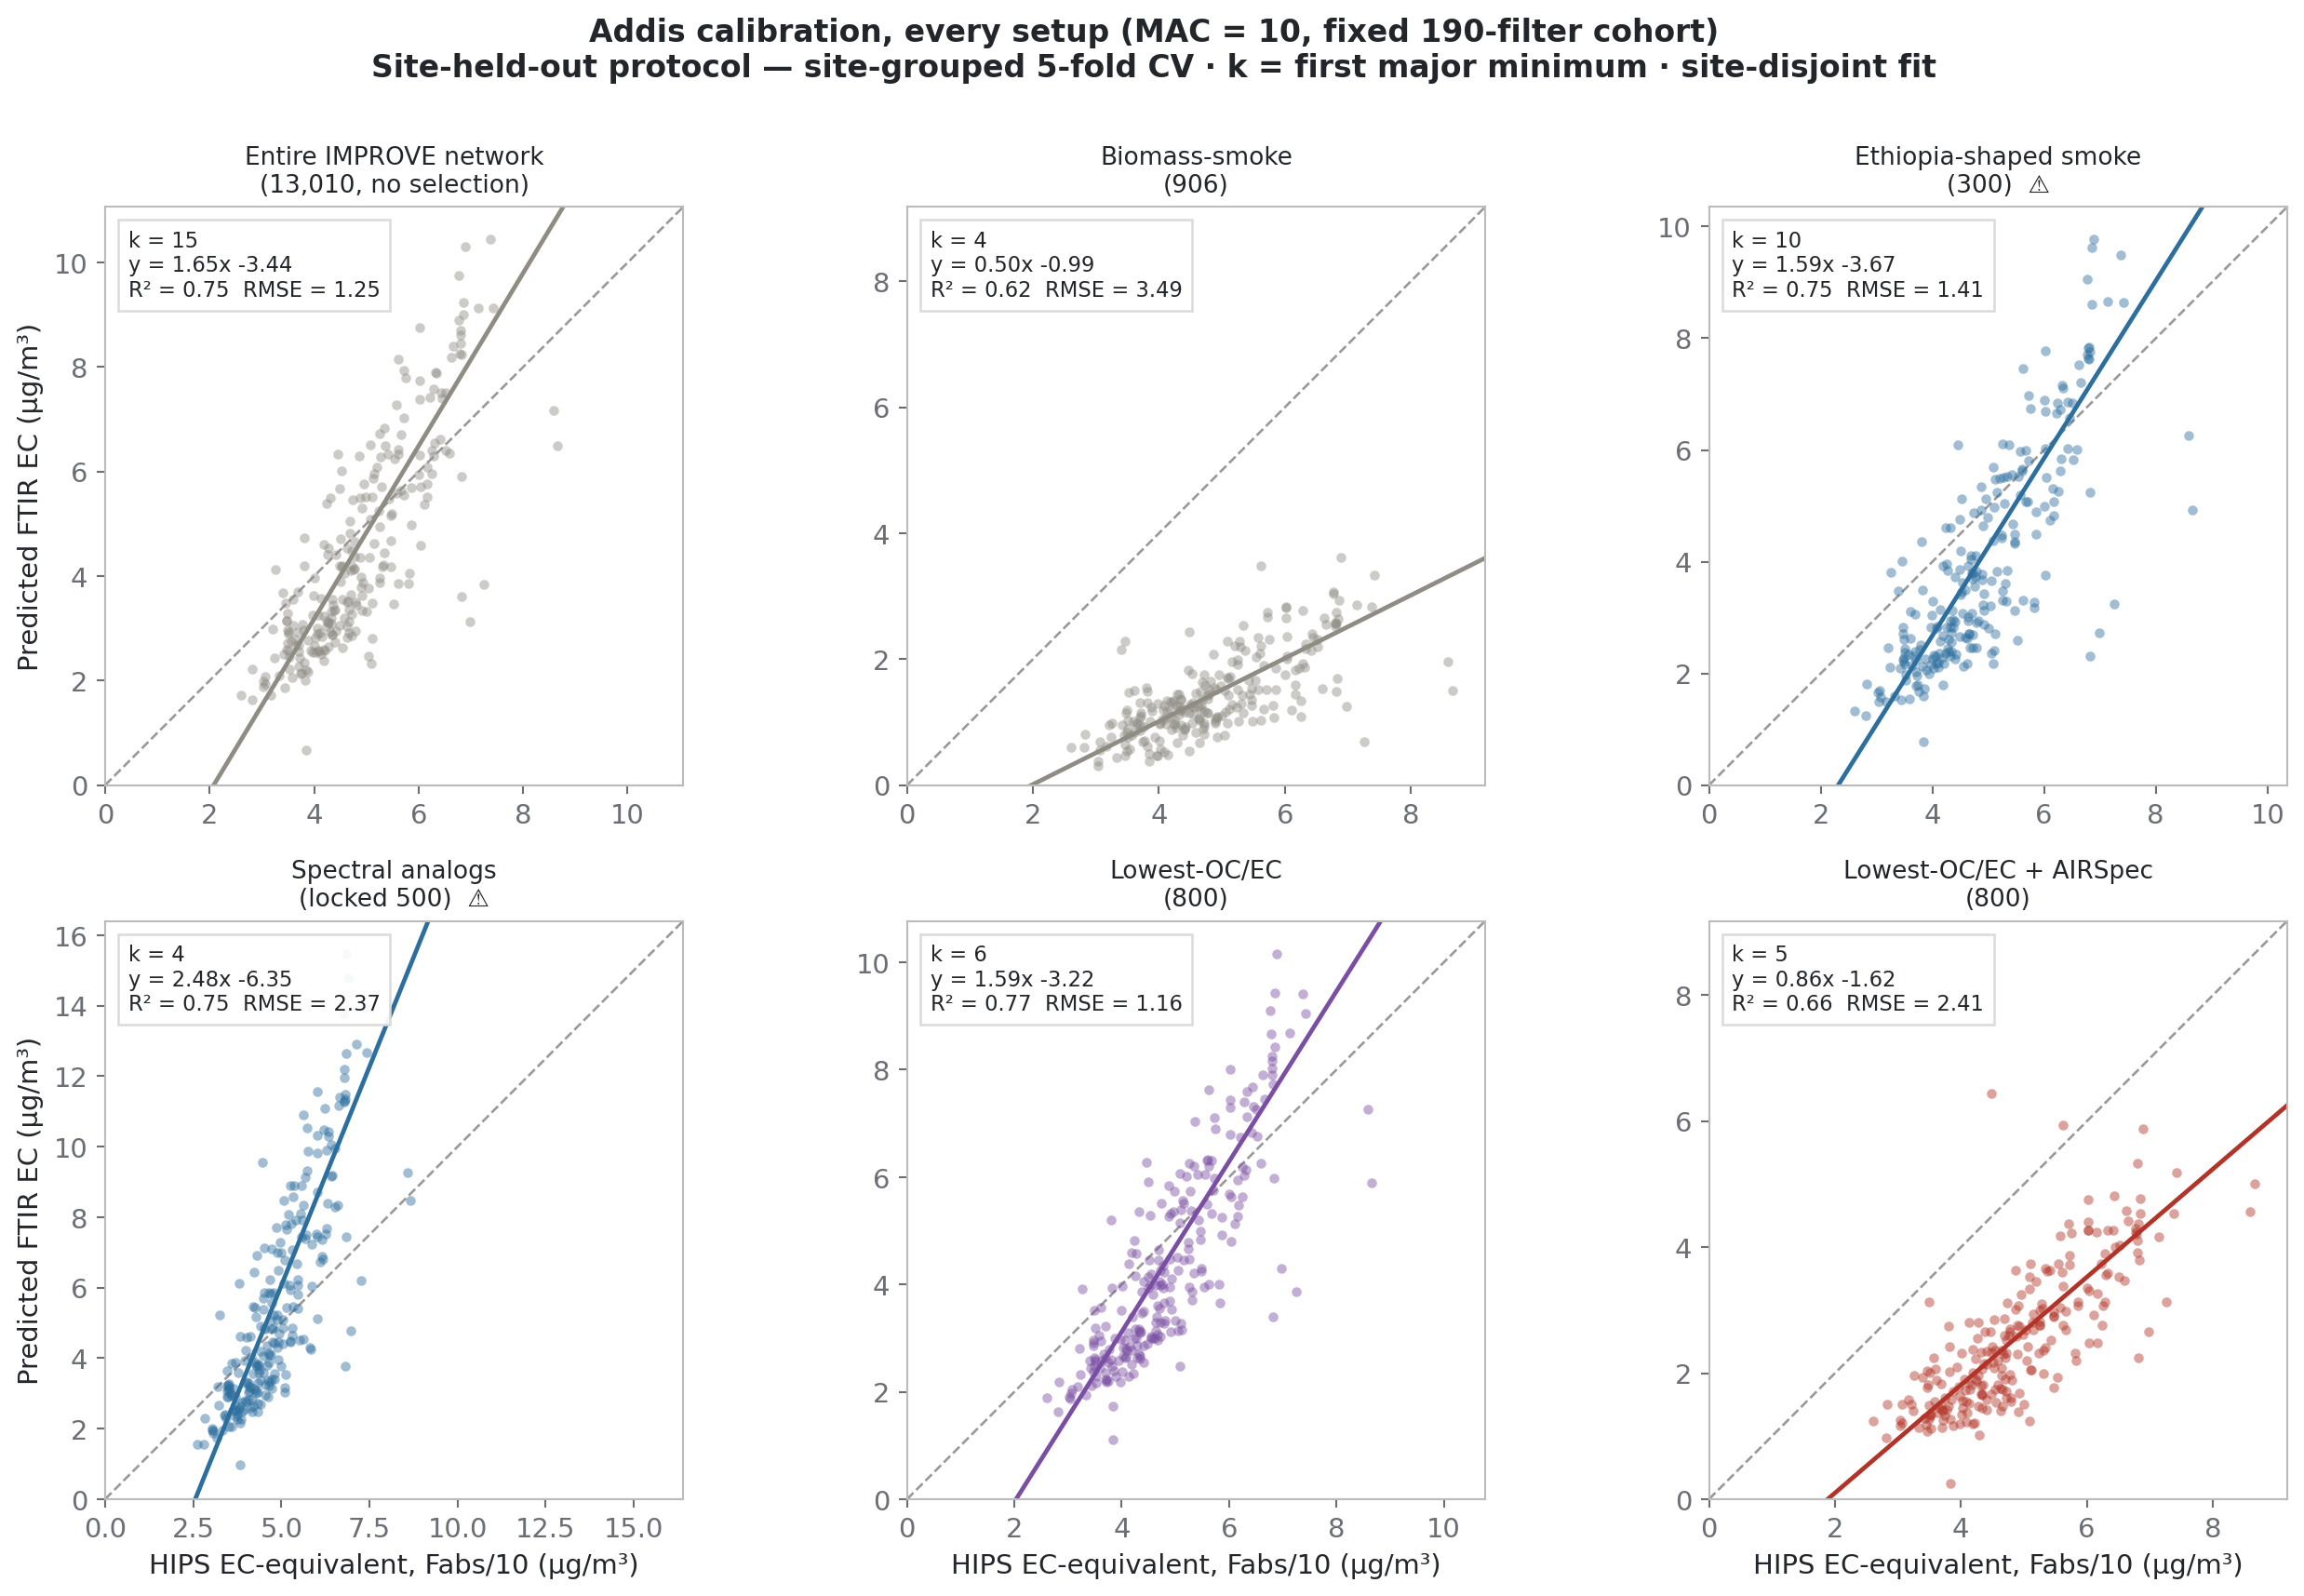

[remade] residual vs D²: output/plots/deck/by_protocol/site_held_out/residual_vs_d2.png


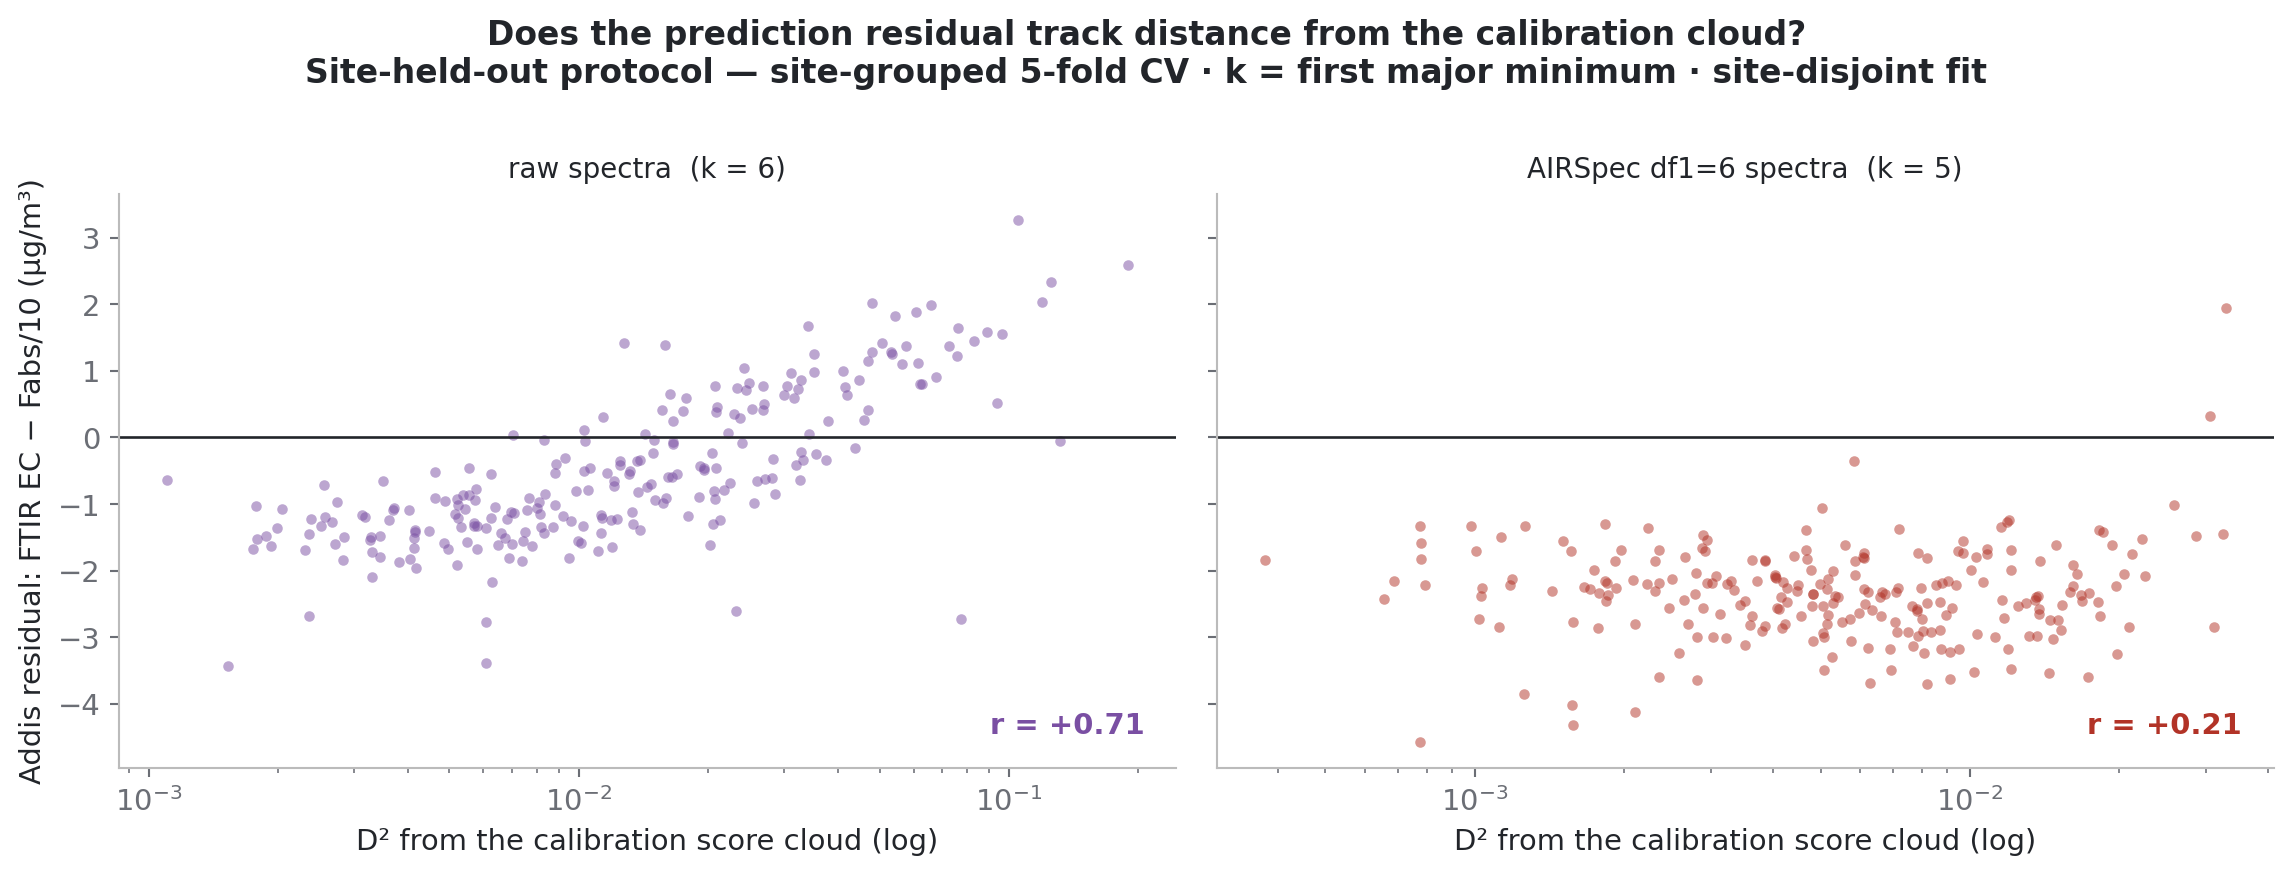

[remade] MAC slope pivot: output/plots/deck/by_protocol/site_held_out/mac_slope_pivot.png


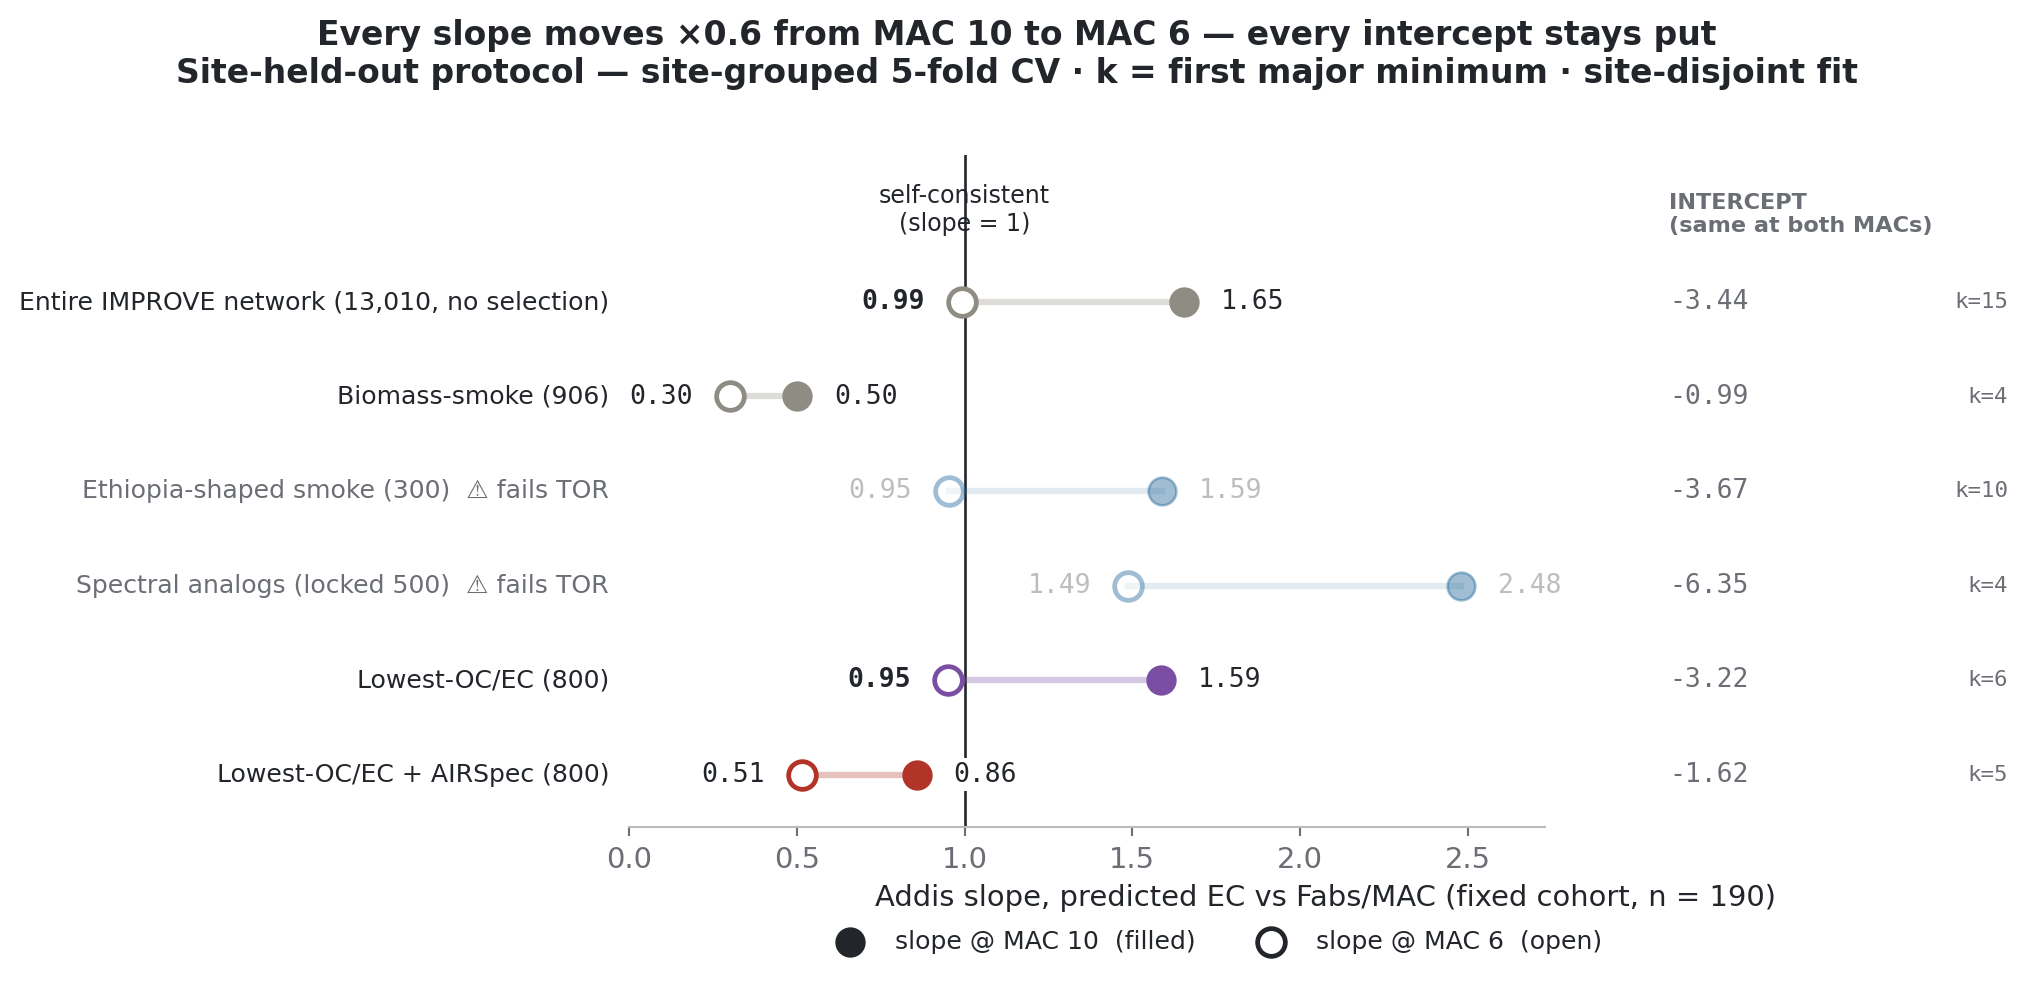

[remade] selection curves (site-held-out): output/plots/deck/by_protocol/site_held_out/component_selection.png


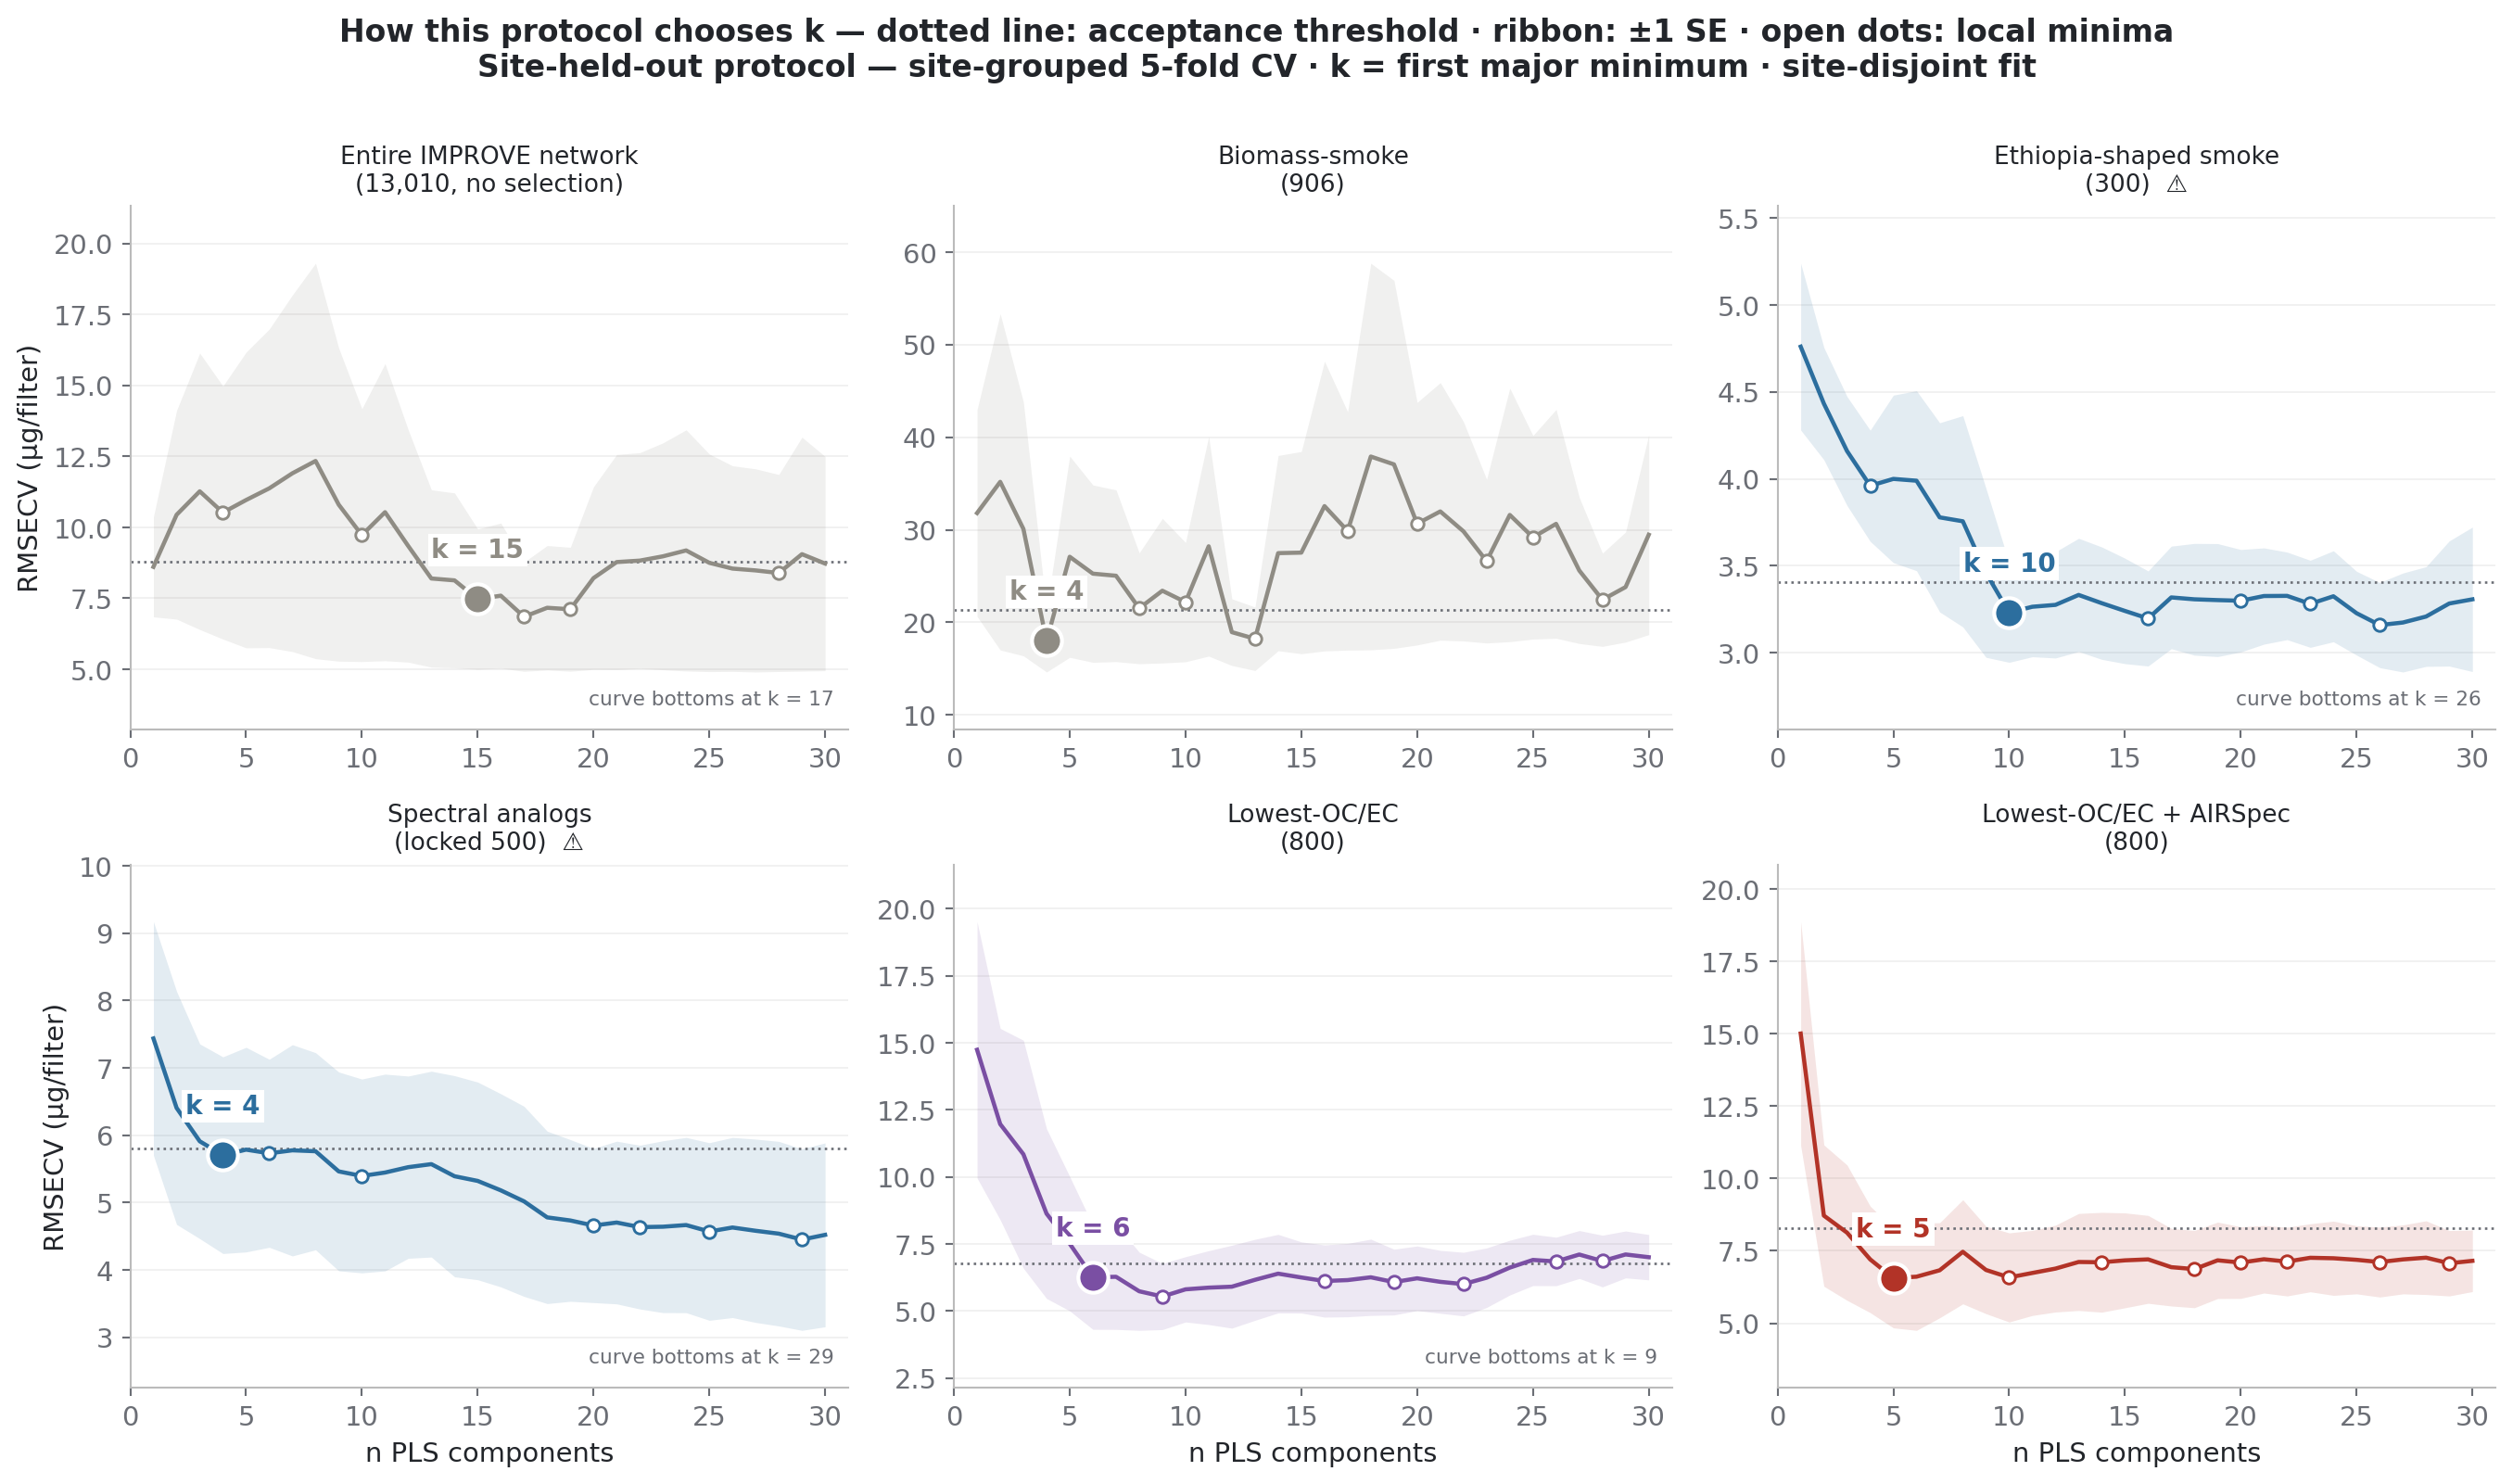

In [2]:
import build_protocol_variants
build_protocol_variants.main()

SHP = DECK / "by_protocol" / "site_held_out"
for name, title in [
    ("calibration_setup_matrix.png", "setup matrix (site-held-out)"),
    ("crossplots_all_setups.png", "six-setup crossplots"),
    ("residual_vs_d2.png", "residual vs D²"),
    ("mac_slope_pivot.png", "MAC slope pivot"),
    ("component_selection.png", "selection curves (site-held-out)"),
]:
    show(SHP / name, title)

### 2. The deck-root figures — filtering strip, matrix, AIRSpec explainers, ladder

[remade] OC/EC filtering strip: output/plots/deck/filtering_by_ocec.png


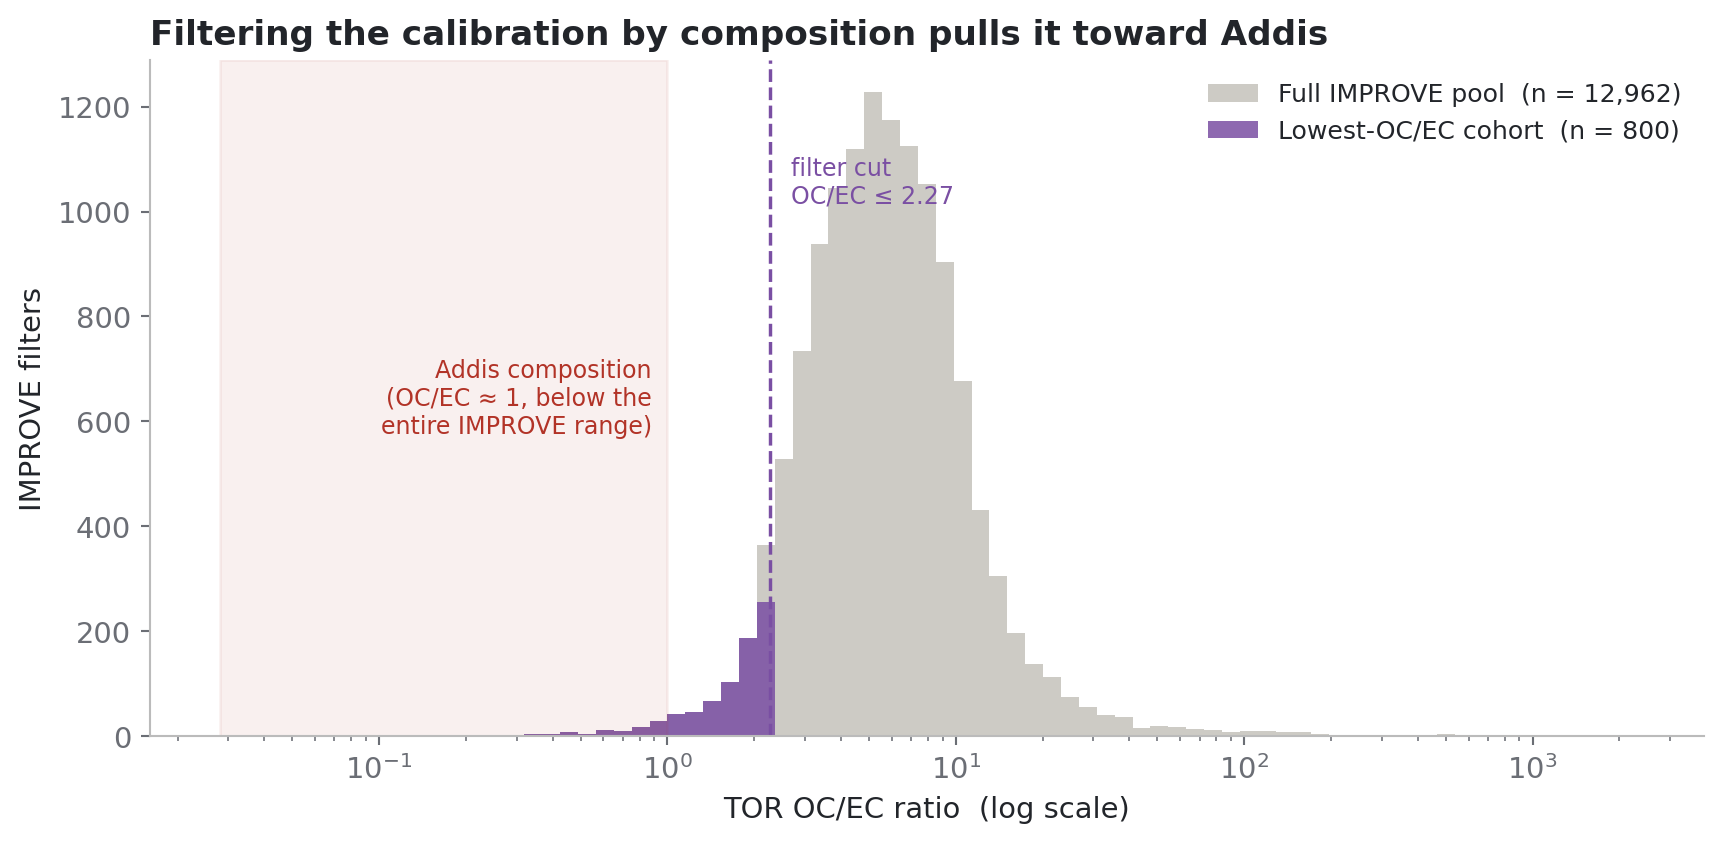

[remade] combined setup matrix: output/plots/deck/calibration_setup_matrix.png


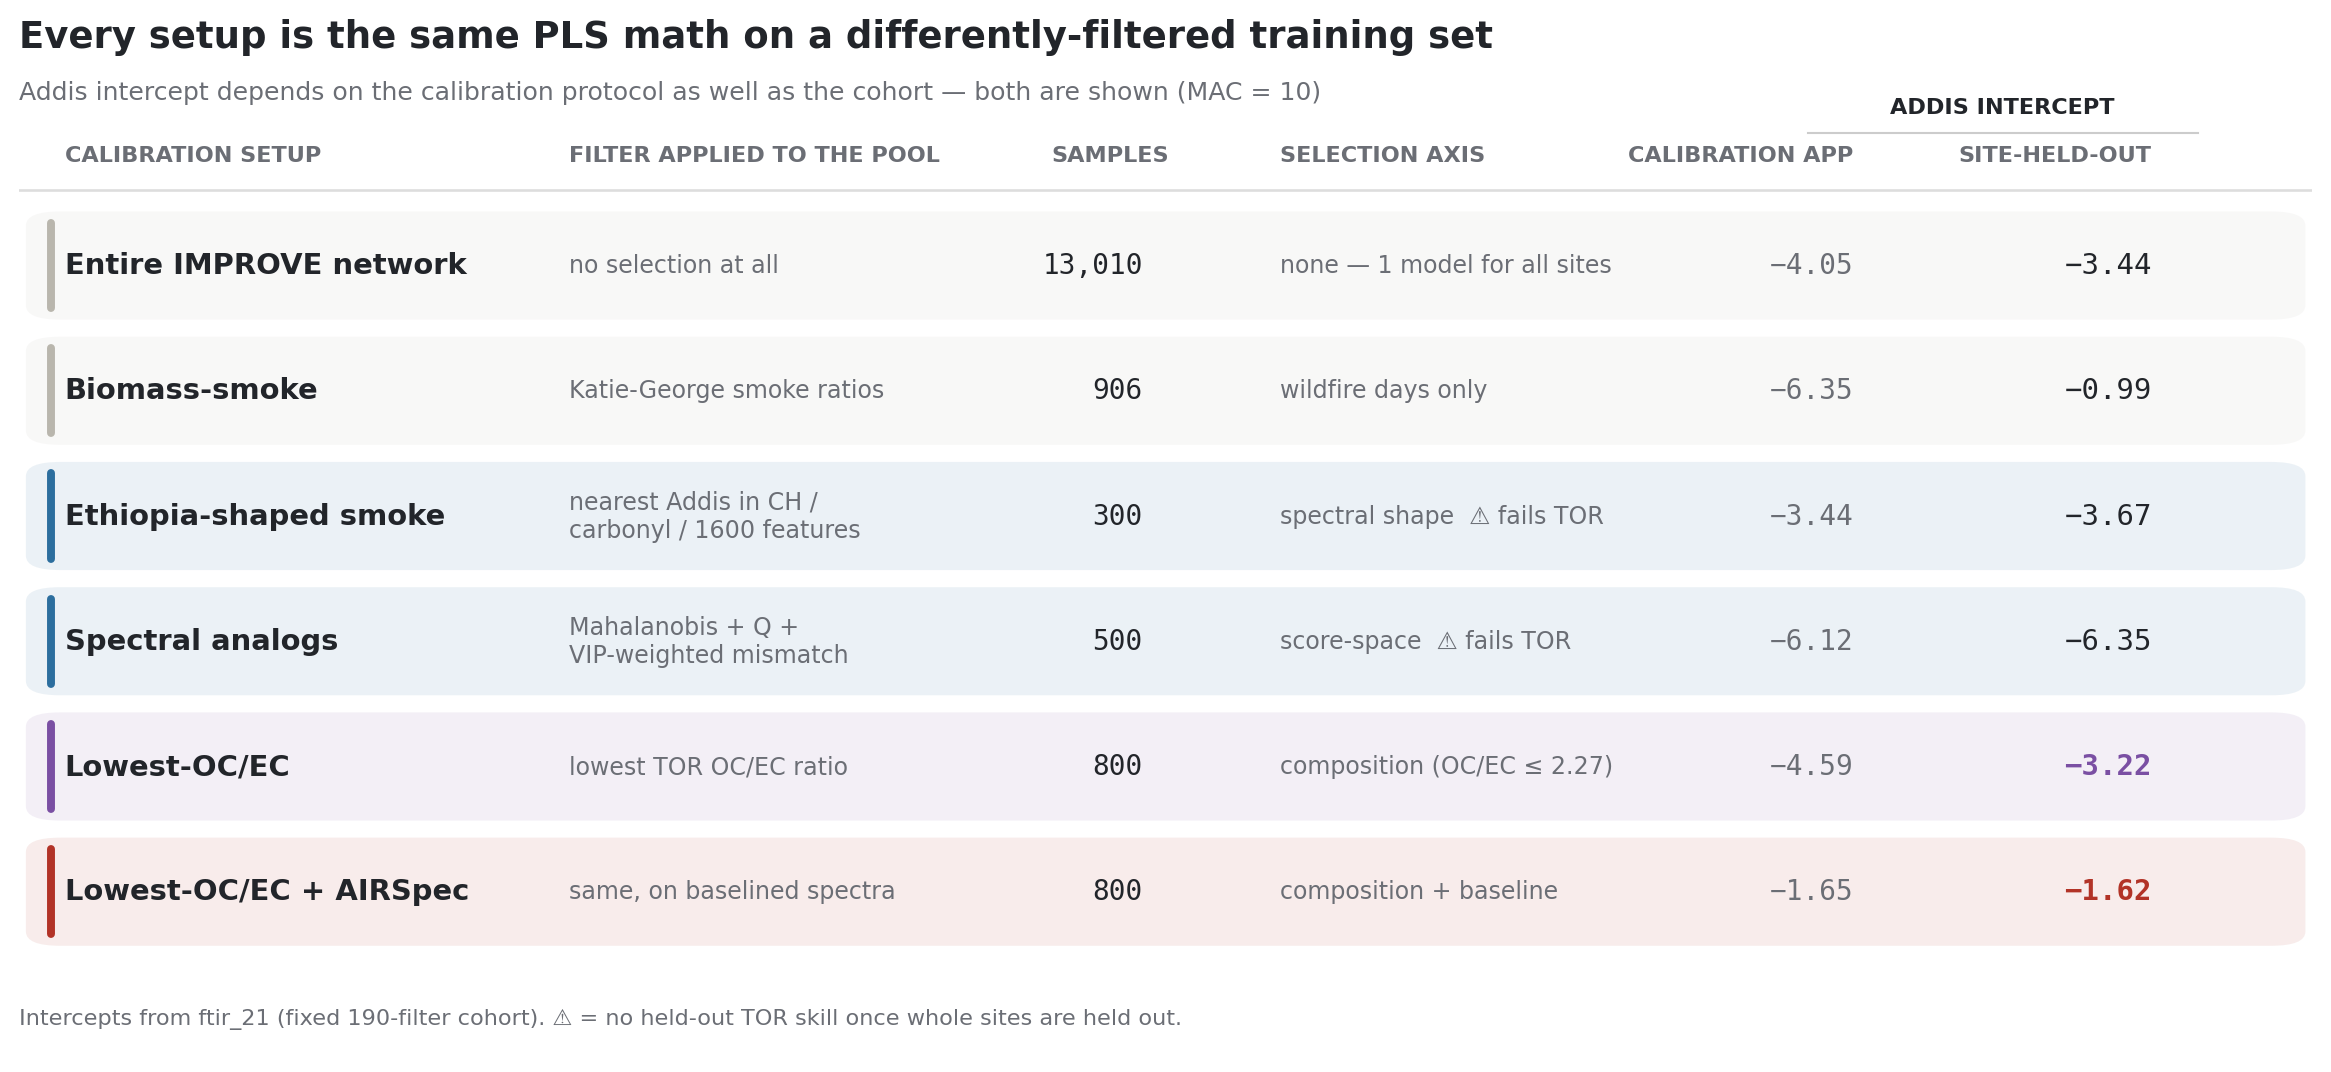

[remade] AIRSpec 1 — baseline: output/plots/deck/airspec_1_baseline.png


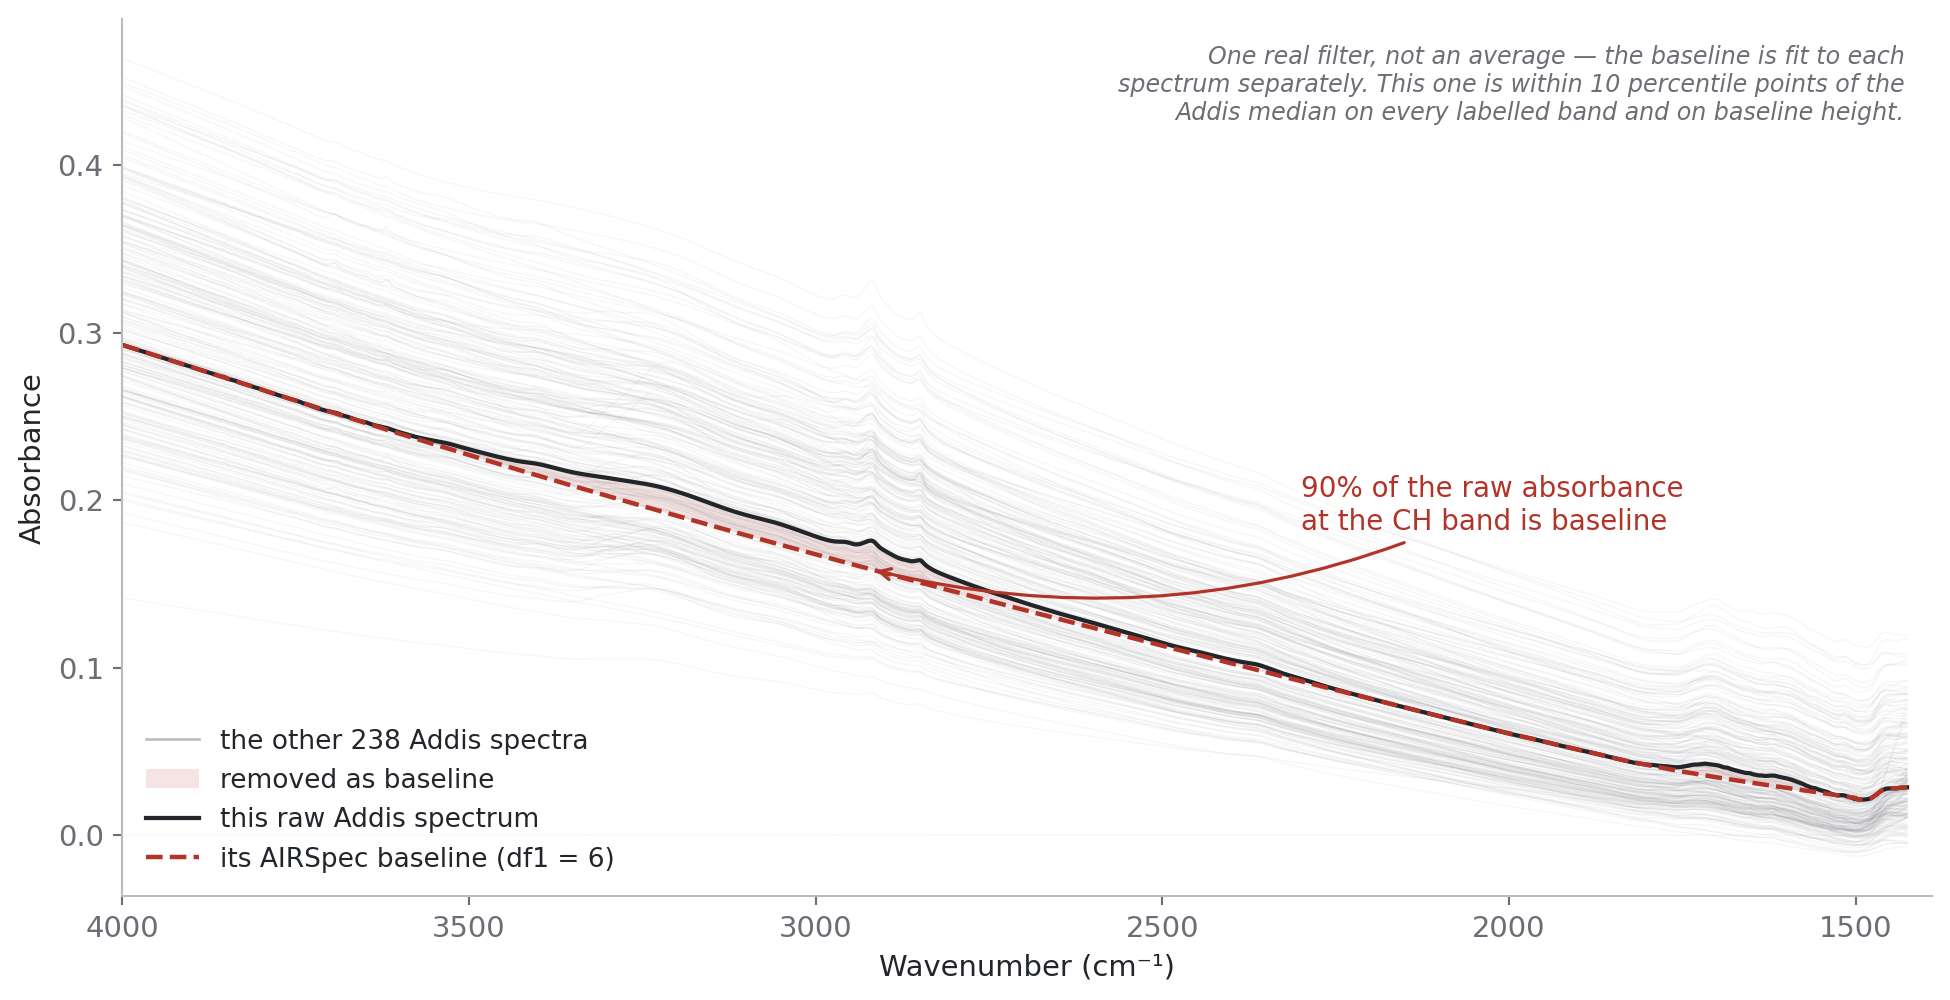

[remade] AIRSpec 2 — corrected: output/plots/deck/airspec_2_corrected.png


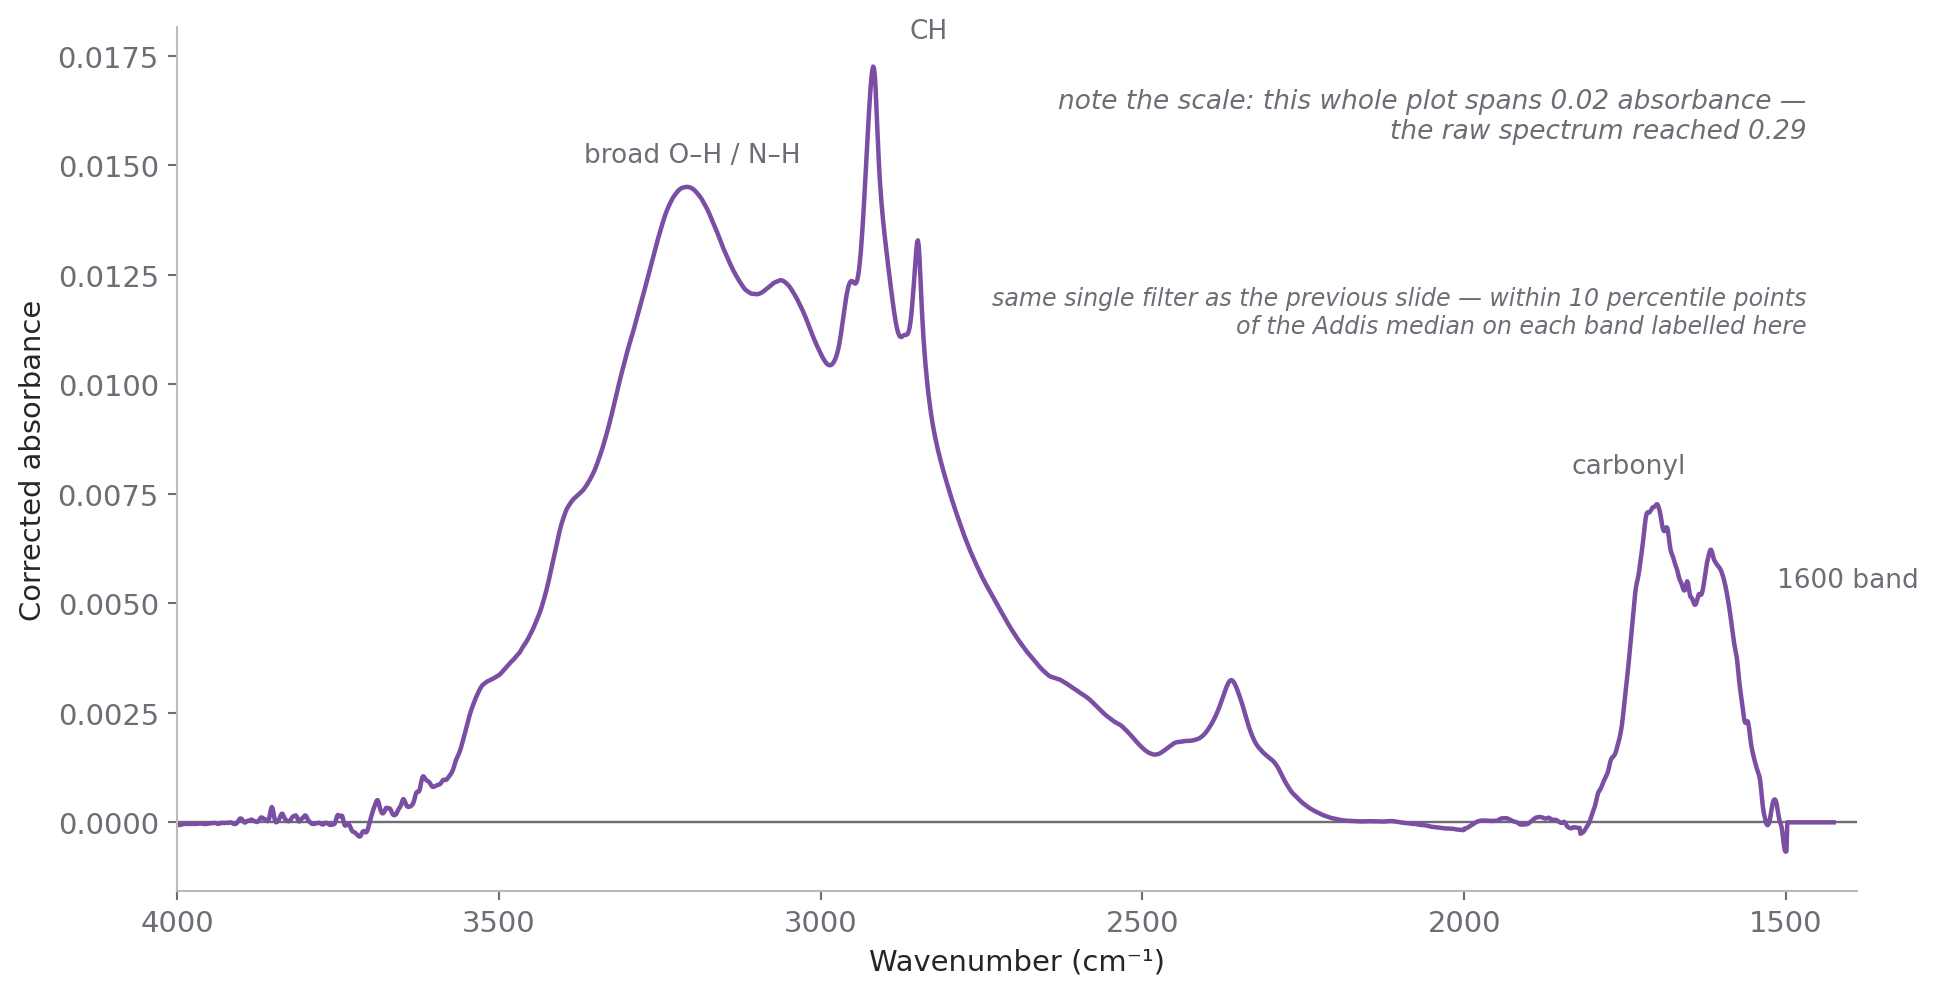

[remade] AIRSpec 3 — background gap: output/plots/deck/airspec_3_background_gap.png


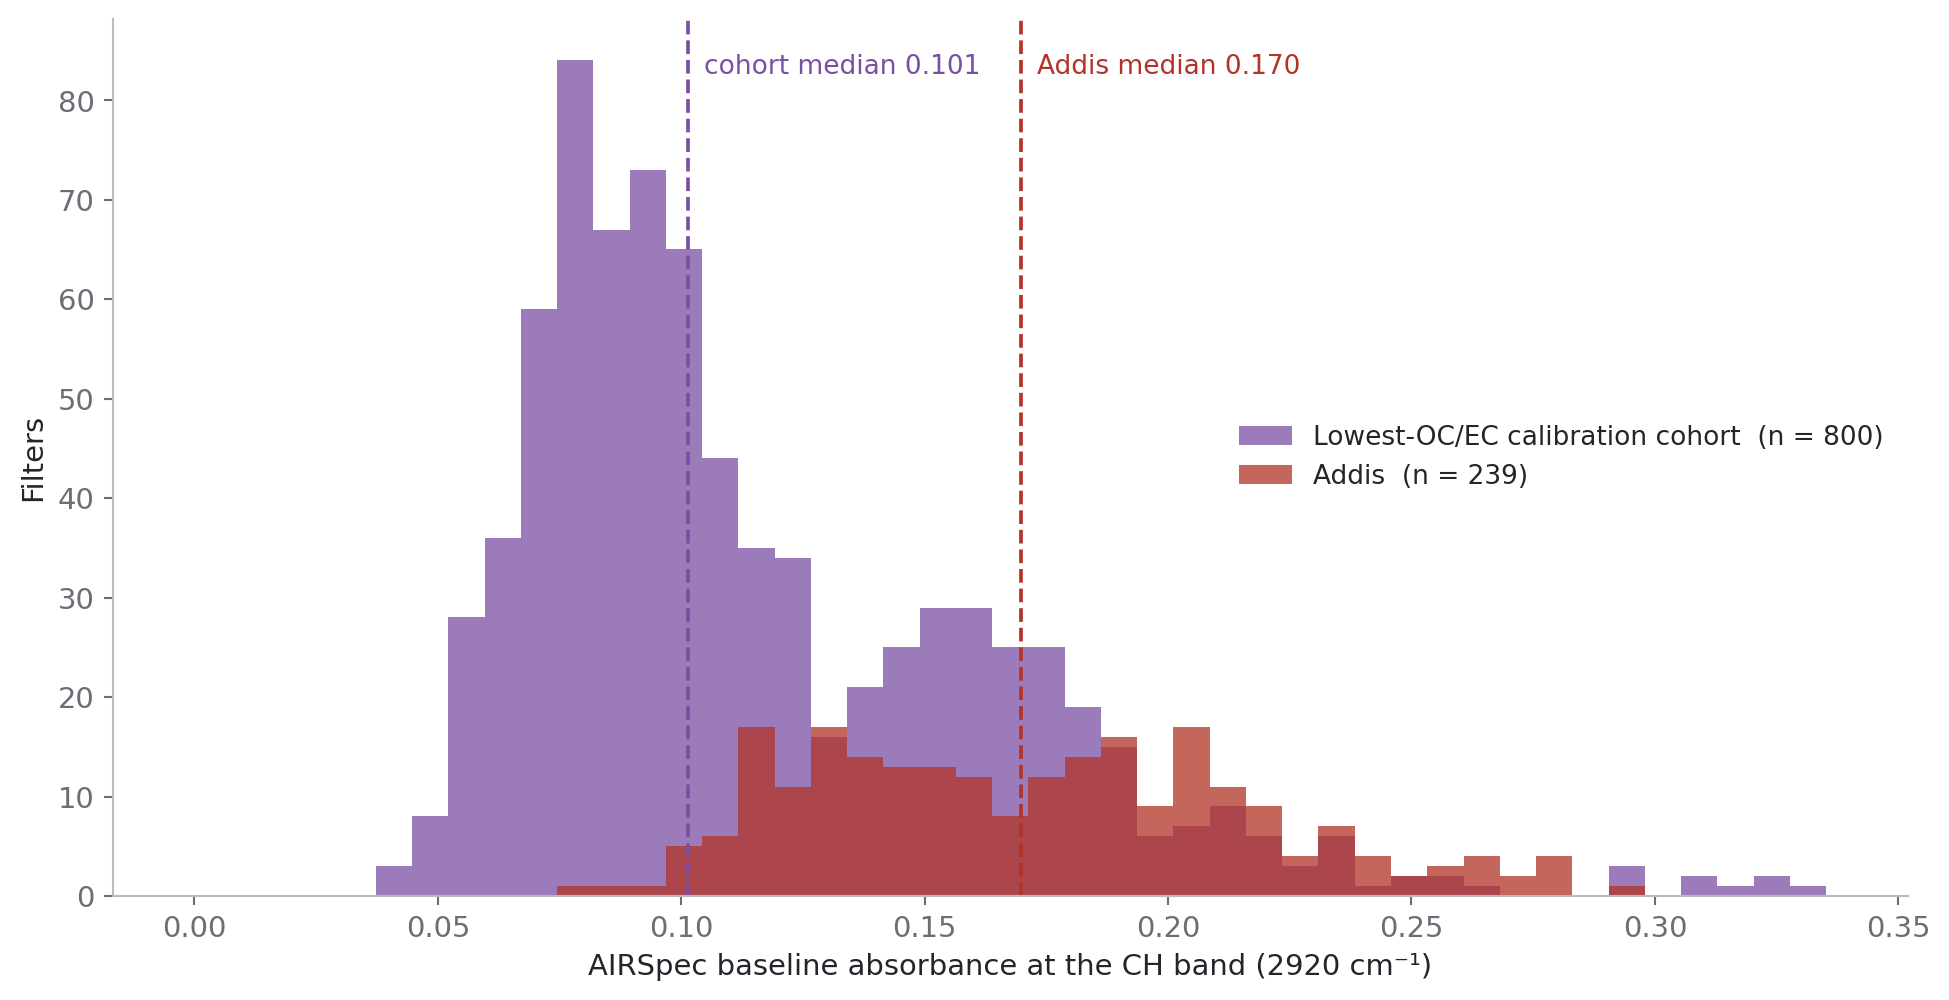

[remade] intercept ladder: output/plots/deck/intercept_ladder.png


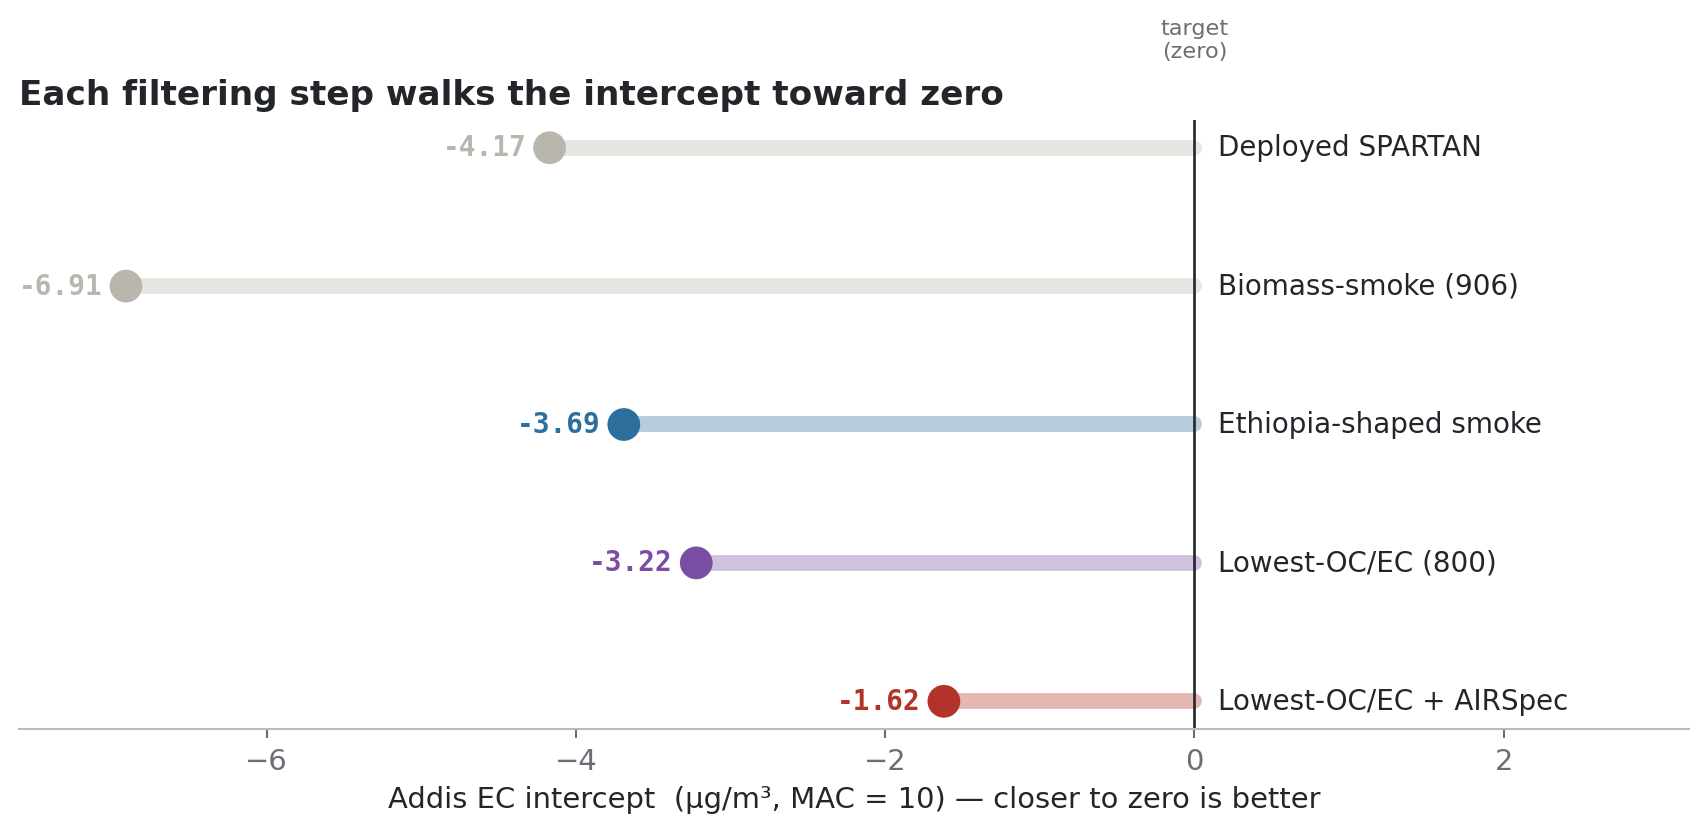

In [3]:
import build_deck_figures as bdf

for fn, name, title in [
    (bdf.fig_filtering_strip, "filtering_by_ocec.png", "OC/EC filtering strip"),
    (bdf.fig_setup_matrix, "calibration_setup_matrix.png", "combined setup matrix"),
    (bdf.fig_airspec_1_baseline, "airspec_1_baseline.png", "AIRSpec 1 — baseline"),
    (bdf.fig_airspec_2_corrected, "airspec_2_corrected.png", "AIRSpec 2 — corrected"),
    (bdf.fig_airspec_3_background_gap, "airspec_3_background_gap.png",
     "AIRSpec 3 — background gap"),
    (bdf.fig_intercept_ladder, "intercept_ladder.png", "intercept ladder"),
]:
    fn()
    show(DECK / name, title)

### 3. The implied-MAC bridge, from the committed 151,843-filter table

Rebuilt directly from `improve_implied_mac_bridge.csv`: implied MAC = Fabs / TOR-EC,
binned by OC/EC decile, with the Addis-like OC/EC ≤ 2.27 region shaded. The headline
numbers are asserted before drawing.

[remade] implied-MAC bridge: output/plots/ftir31/improve_implied_mac_curve.png


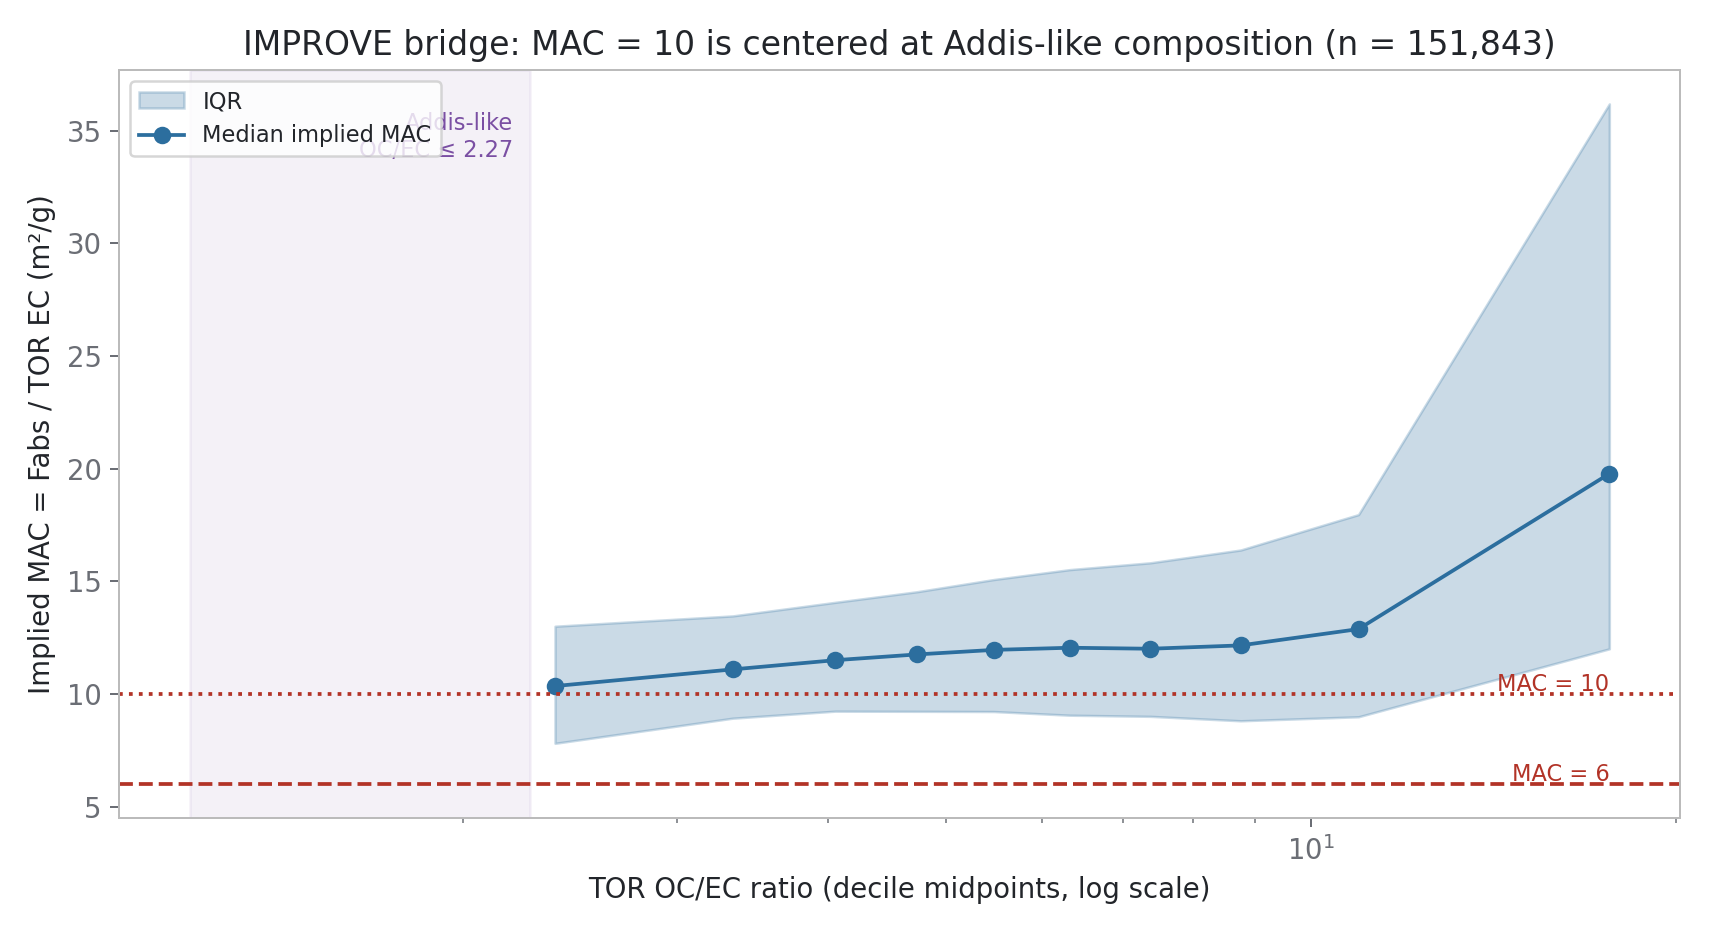

In [4]:
bridge = pd.read_csv("output/tables/ftir16/improve_implied_mac_bridge.csv")
bridge = bridge[(bridge.EC_ugm3 > 0) & (bridge.Fabs > 0)].copy()
assert len(bridge) == 151_843, len(bridge)
med = bridge.implied_MAC.median()
sub = bridge[bridge.OC_EC <= 2.27]
assert round(med, 2) == 11.96, med
assert (len(sub), round(sub.implied_MAC.median(), 2)) == (6503, 10.05)

dec = pd.qcut(bridge.OC_EC, 10)
g = bridge.groupby(dec, observed=True)
mid = g.OC_EC.median()
q1, q2, q3 = (g.implied_MAC.quantile(q) for q in (0.25, 0.5, 0.75))

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.fill_between(mid, q1, q3, alpha=0.25, color=BLUE, label="IQR")
ax.plot(mid, q2, "o-", color=BLUE, label="Median implied MAC")
ax.axhline(10, color=ACCENT, ls=":", lw=1.5)
ax.axhline(6, color=ACCENT, ls="--", lw=1.5)
ax.text(mid.iloc[-1], 10.15, "MAC = 10", color=ACCENT, ha="right", fontsize=9)
ax.text(mid.iloc[-1], 6.15, "MAC = 6", color=ACCENT, ha="right", fontsize=9)
ax.axvspan(mid.min() * 0.5, 2.27, color=PURPLE, alpha=0.08)
ax.text(2.2, ax.get_ylim()[1] * 0.95, "Addis-like\nOC/EC ≤ 2.27", color=PURPLE,
        ha="right", va="top", fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("TOR OC/EC ratio (decile midpoints, log scale)")
ax.set_ylabel("Implied MAC = Fabs / TOR EC (m²/g)")
ax.set_title(f"IMPROVE bridge: MAC = 10 is centered at Addis-like composition "
             f"(n = {len(bridge):,})")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
fig.savefig(OUT / "improve_implied_mac_curve.png", dpi=180)
plt.close(fig)
show(OUT / "improve_implied_mac_curve.png", "implied-MAC bridge")

### 4. The deployed crossplot, from committed phase-2 predictions

The fixed 190-filter cohort is the complete-rows subset of
`addis_calibration_predictions.csv`. Both MAC panels are refit here and the deck's
headline equation asserted.

[remade] deployed crossplot: output/plots/ftir31/deployed_alldata_crossplot.png


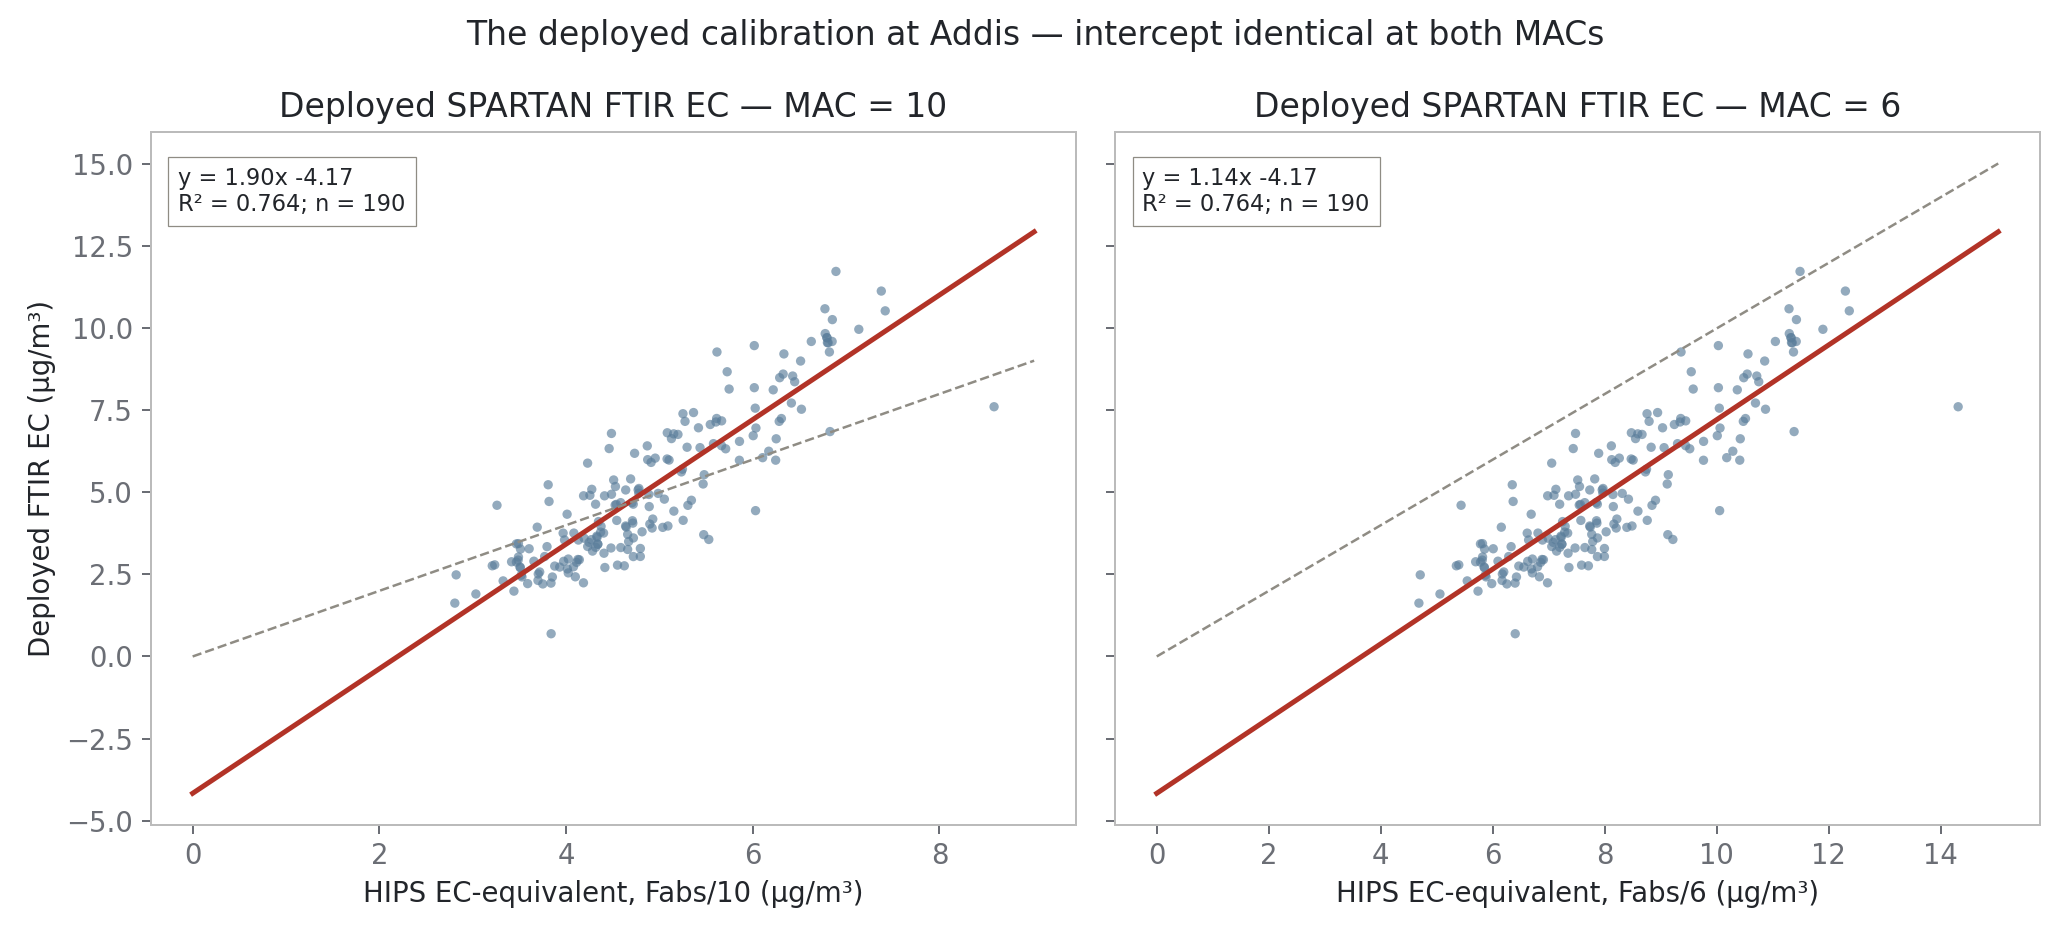

In [5]:
pred = pd.read_csv(Path("..") / "ftir_hips_chem" / "output" / "tables"
                   / "pls_calibration_phase2" / "addis_calibration_predictions.csv")
fixed = pred.dropna(axis=0, how="any").copy()
assert len(fixed) == 190, len(fixed)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2), sharey=True)
for ax, mac in zip(axes, (10, 6)):
    x = fixed.Fabs / mac
    y = fixed.EC_deployed_ugm3
    slope, inter = np.polyfit(x, y, 1)
    r2 = np.corrcoef(x, y)[0, 1] ** 2
    if mac == 10:
        assert (round(slope, 2), round(inter, 2)) == (1.90, -4.17), (slope, inter)
    else:
        assert round(slope, 2) == 1.14, slope
    ax.scatter(x, y, s=14, color="#5a7d9a", alpha=0.65, edgecolor="none")
    hi = float(x.max()) * 1.05
    ax.plot([0, hi], [inter, inter + slope * hi], color=ACCENT, lw=2)
    ax.plot([0, hi], [0, hi], color=GREY, ls="--", lw=1)
    ax.set_title(f"Deployed SPARTAN FTIR EC — MAC = {mac}")
    ax.set_xlabel(f"HIPS EC-equivalent, Fabs/{mac} (µg/m³)")
    ax.text(0.03, 0.95, f"y = {slope:.2f}x {inter:+.2f}\nR² = {r2:.3f}; n = {len(fixed)}",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(fc="white", ec=GREY, lw=0.5))
axes[0].set_ylabel("Deployed FTIR EC (µg/m³)")
fig.suptitle("The deployed calibration at Addis — intercept identical at both MACs")
fig.tight_layout()
fig.savefig(OUT / "deployed_alldata_crossplot.png", dpi=180)
plt.close(fig)
show(OUT / "deployed_alldata_crossplot.png", "deployed crossplot")

### 5. Seasonal corrected spectra — npz cache joined to committed seasons

The corrected ETAD spectra cache carries `media_id`; the phase-2 predictions table
carries each MediaId's season label (dry_feb convention). Median ± 10–90 % per season.

spectra joined to a season: 259 of 319


[remade] seasonal corrected spectra: output/plots/ftir31/addis_spectra_by_season_corrected.png


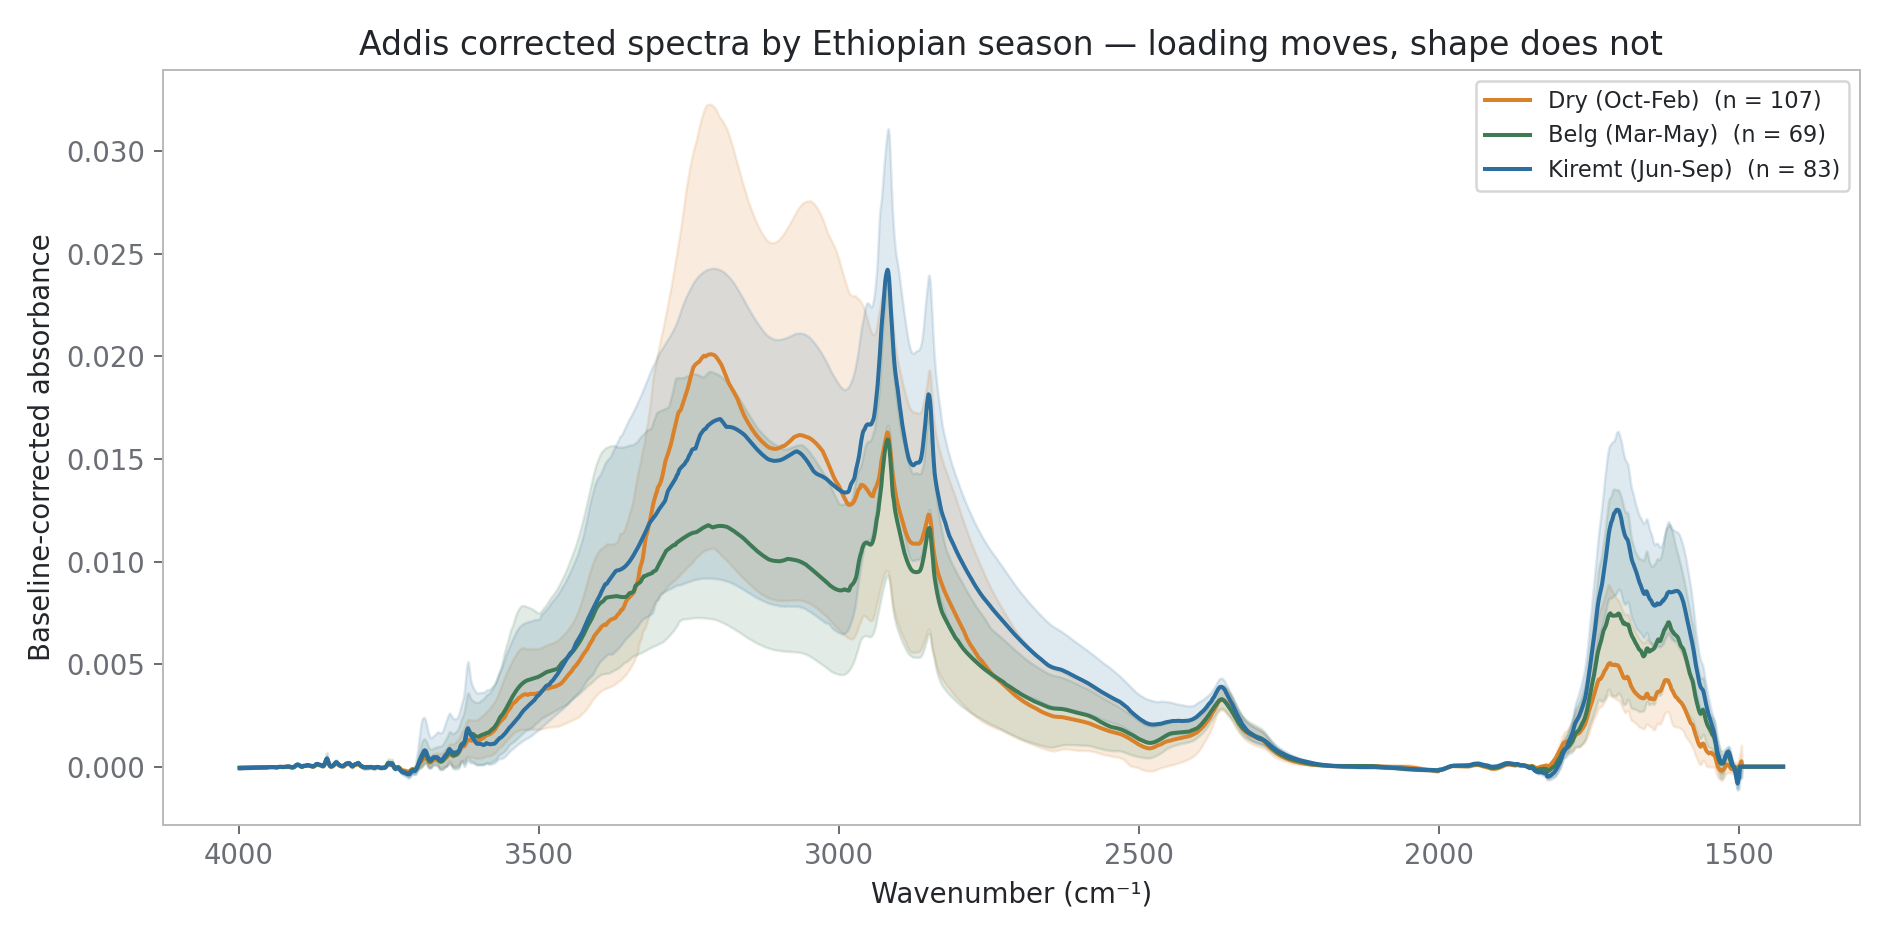

In [6]:
z = np.load("output/corrected/etad_corrected_df6.npz", allow_pickle=True)
wn, corr, media = z["wn"], z["corrected"], z["media_id"]
season_of = dict(zip(pred.MediaId, pred.season))
mask = np.array([m in season_of for m in media])
labels = np.array([season_of.get(m, "") for m in media])
print(f"spectra joined to a season: {mask.sum()} of {len(media)}")

fig, ax = plt.subplots(figsize=(10.5, 5.2))
colors = {"Dry (Oct-Feb)": "#D9822B", "Belg (Mar-May)": "#3F7A56",
          "Kiremt (Jun-Sep)": BLUE}
for season, color in colors.items():
    sel = corr[mask & (labels == season)]
    if not len(sel):
        continue
    ax.fill_between(wn, np.percentile(sel, 10, axis=0), np.percentile(sel, 90, axis=0),
                    color=color, alpha=0.15)
    ax.plot(wn, np.median(sel, axis=0), color=color, lw=1.6,
            label=f"{season}  (n = {len(sel)})")
ax.invert_xaxis()
ax.set_xlabel("Wavenumber (cm⁻¹)")
ax.set_ylabel("Baseline-corrected absorbance")
ax.set_title("Addis corrected spectra by Ethiopian season — loading moves, shape does not")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(OUT / "addis_spectra_by_season_corrected.png", dpi=180)
plt.close(fig)
show(OUT / "addis_spectra_by_season_corrected.png", "seasonal corrected spectra")

### 6. The 1600-band peak centers — committed group stats, drawn

Stats-faithful remake: per-group median and IQR from `peak_center_1600_stats.csv`.
The per-filter histogram version is ftir_12's figure (`build_notebooks.py 12`).

[remade] 1600-band peak centers (stats panel): output/plots/ftir31/peak_center_1600_stats_panel.png


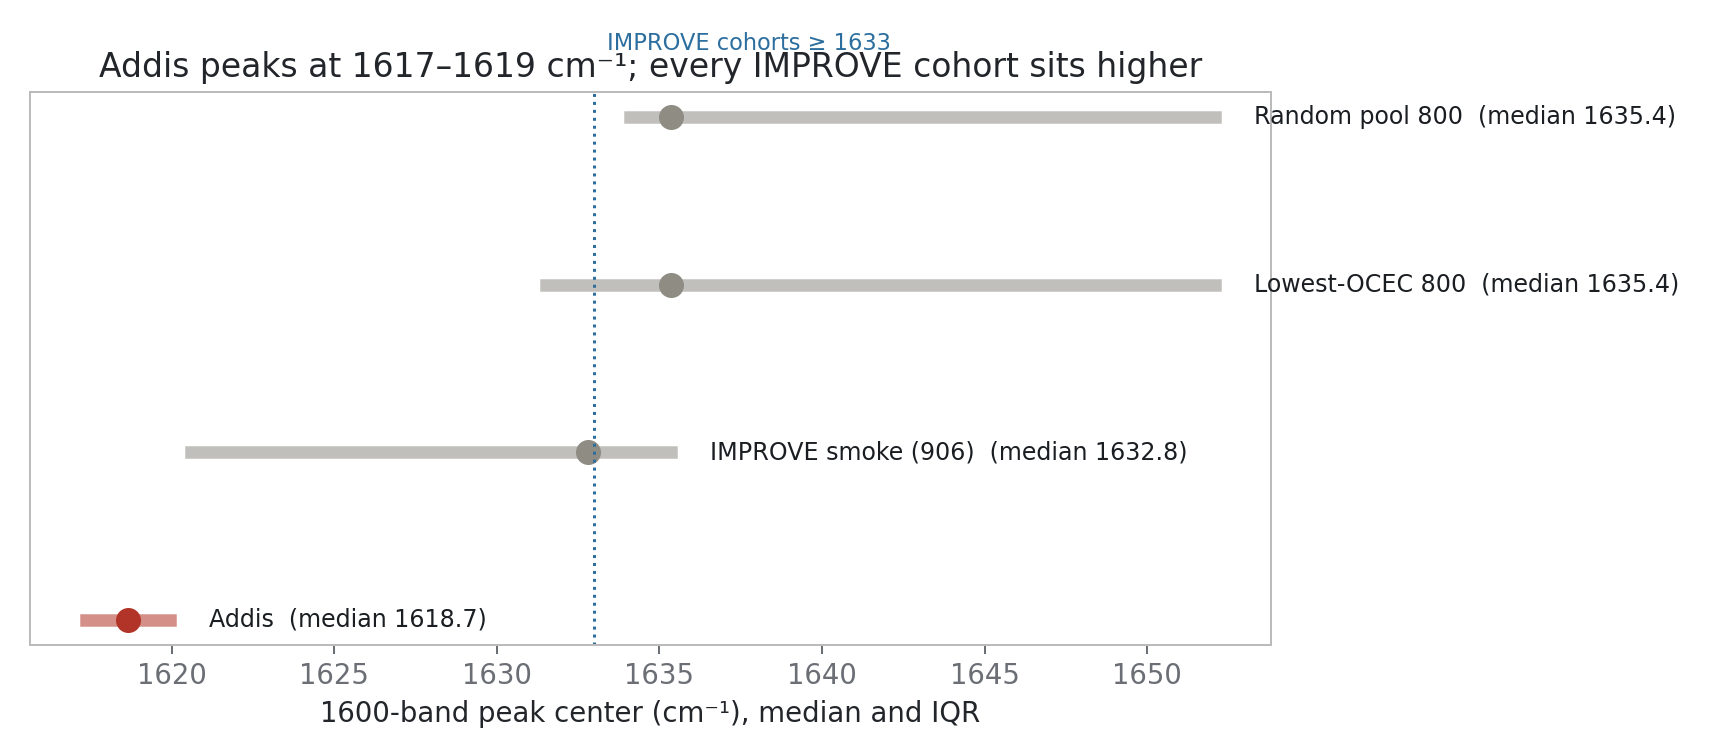

In [7]:
pk = pd.read_csv("output/tables/ftir12/peak_center_1600_stats.csv")
addis = pk[pk.group.str.contains("Addis", case=False)].iloc[0]
assert 1617 <= addis.center_median <= 1619.5, addis.center_median

pk = pk.sort_values("center_median")
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ypos = np.arange(len(pk))
for y, (_, row) in zip(ypos, pk.iterrows()):
    is_addis = "addis" in row.group.lower()
    c = ACCENT if is_addis else GREY
    ax.plot([row.center_p25, row.center_p75], [y, y], color=c, lw=5, alpha=0.55)
    ax.plot(row.center_median, y, "o", color=c, ms=9)
    ax.text(row.center_p75 + 1.2, y, f"{row.group}  (median {row.center_median:.1f})",
            va="center", fontsize=9.5, color="#1A1D21")
ax.axvline(1633, color=BLUE, ls=":", lw=1.2)
ax.text(1633.4, len(pk) - 0.6, "IMPROVE cohorts ≥ 1633", color=BLUE, fontsize=9)
ax.set_yticks([])
ax.set_xlabel("1600-band peak center (cm⁻¹), median and IQR")
ax.set_title("Addis peaks at 1617–1619 cm⁻¹; every IMPROVE cohort sits higher")
fig.tight_layout()
fig.savefig(OUT / "peak_center_1600_stats_panel.png", dpi=180)
plt.close(fig)
show(OUT / "peak_center_1600_stats_panel.png", "1600-band peak centers (stats panel)")

### 7. Adama & Bishoftu context — SPARTAN HIPS export + committed Adama TOR

[remade] Adama/ETBI context: output/plots/ftir31/adama_etbi_context.png


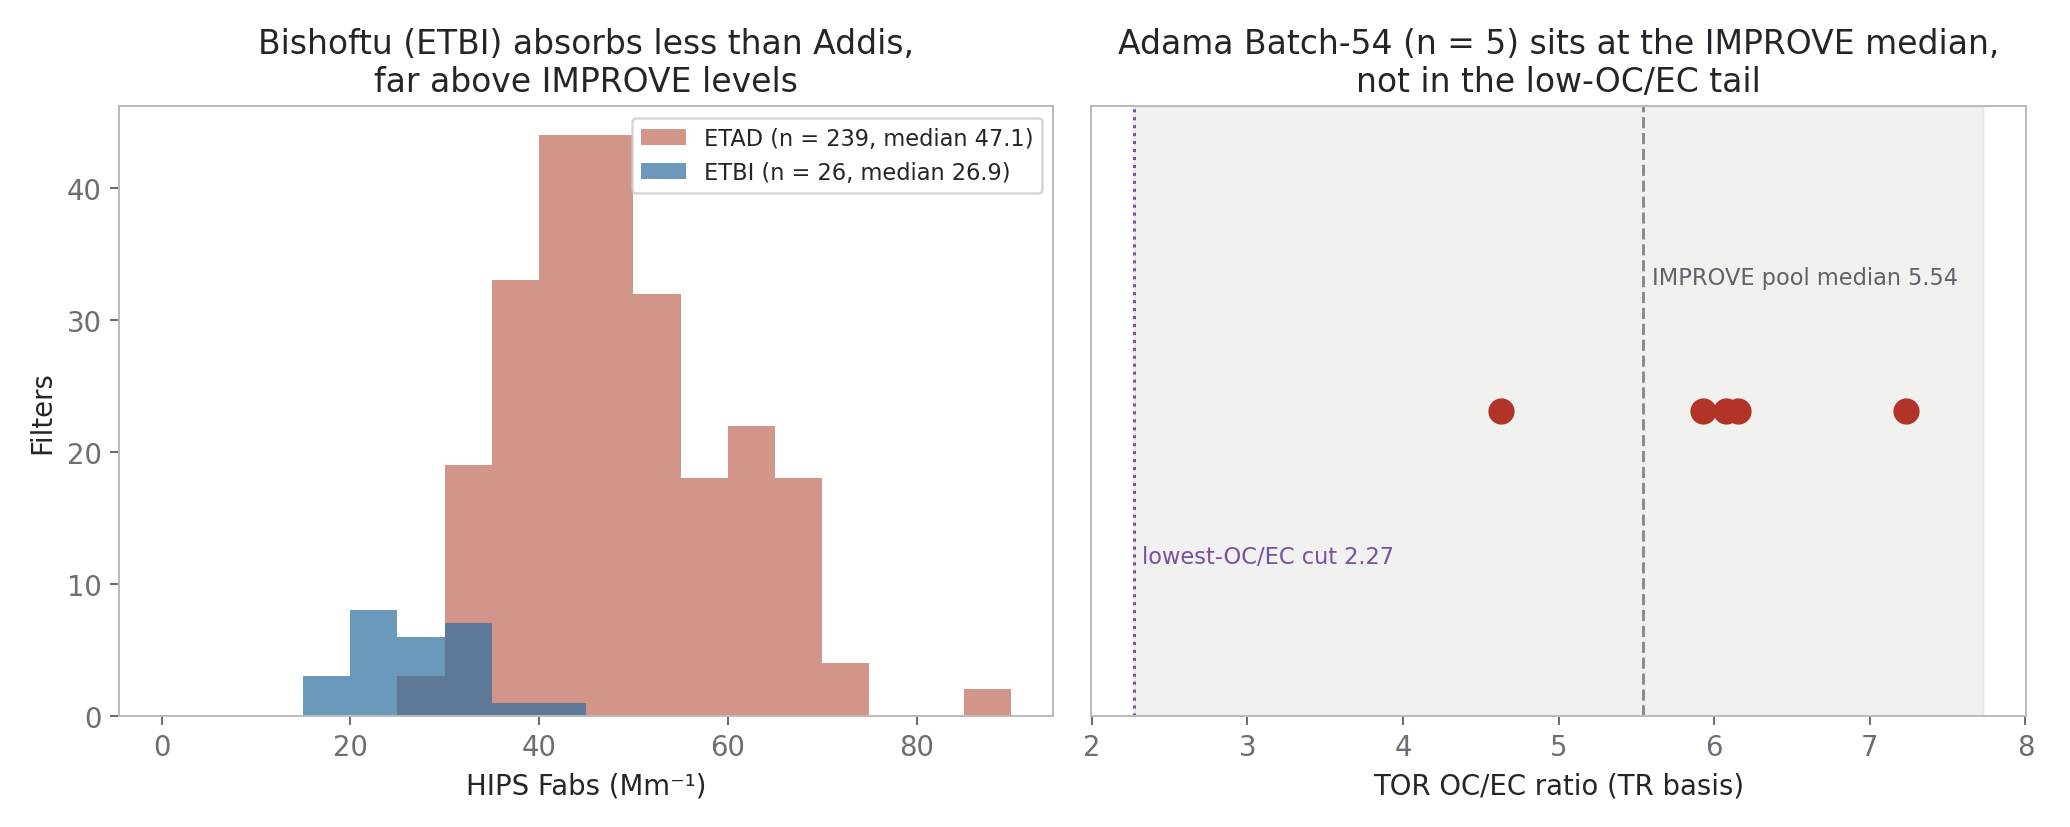

In [8]:
import data_paths
hips = pd.read_csv(Path(data_paths.maia_data_root()) / "Spartan"
                   / "SPARTAN_HIPS_Batch1-51.v2.csv")
site_col = next(c for c in hips.columns if "site" in c.lower())
fabs_col = next(c for c in hips.columns if "fabs" in c.lower())
etad = pd.to_numeric(hips.loc[hips[site_col] == "ETAD", fabs_col], errors="coerce").dropna()
etbi = pd.to_numeric(hips.loc[hips[site_col] == "ETBI", fabs_col], errors="coerce").dropna()
assert round(etad.median(), 1) == 47.1, etad.median()
assert round(etbi.median(), 1) == 26.9, etbi.median()

adama = pd.read_csv("output/tables/ftir16/adama_batch54_ocec.csv")
ratios = adama.OC_EC_TR
assert 4.5 <= ratios.min() and ratios.max() <= 7.3

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
bins = np.arange(0, 95, 5)
axes[0].hist(etad, bins=bins, color="#C97B6D", alpha=0.8,
             label=f"ETAD (n = {len(etad)}, median {etad.median():.1f})")
axes[0].hist(etbi, bins=bins, color=BLUE, alpha=0.7,
             label=f"ETBI (n = {len(etbi)}, median {etbi.median():.1f})")
axes[0].set_xlabel("HIPS Fabs (Mm⁻¹)")
axes[0].set_ylabel("Filters")
axes[0].set_title("Bishoftu (ETBI) absorbs less than Addis,\nfar above IMPROVE levels")
axes[0].legend(fontsize=9)
axes[1].scatter(ratios, np.zeros(len(ratios)), s=90, color=ACCENT, zorder=3)
axes[1].axvspan(2.27, ratios.max() + 0.5, color=GREY, alpha=0.12)
axes[1].axvline(5.54, color=GREY, ls="--", lw=1.2)
axes[1].text(5.6, 0.25, "IMPROVE pool median 5.54", fontsize=9, color="#5E6369")
axes[1].axvline(2.27, color=PURPLE, ls=":", lw=1.2)
axes[1].text(2.32, -0.3, "lowest-OC/EC cut 2.27", fontsize=9, color=PURPLE)
axes[1].set_ylim(-0.6, 0.6)
axes[1].set_yticks([])
axes[1].set_xlabel("TOR OC/EC ratio (TR basis)")
axes[1].set_title(f"Adama Batch-54 (n = {len(adama)}) sits at the IMPROVE median,\n"
                  "not in the low-OC/EC tail")
fig.tight_layout()
fig.savefig(OUT / "adama_etbi_context.png", dpi=180)
plt.close(fig)
show(OUT / "adama_etbi_context.png", "Adama/ETBI context")

### 8. Manifest — where every deck image now traces

In [9]:
manifest = pd.DataFrame([
    ("calibration_setup_matrix", "by_protocol (both)", "this notebook §1 → build_protocol_variants"),
    ("crossplots_all_setups", "by_protocol (both)", "this notebook §1"),
    ("residual_vs_d2", "by_protocol (both)", "this notebook §1"),
    ("mac_slope_pivot", "by_protocol (both)", "this notebook §1"),
    ("component_selection / selection curves", "by_protocol (both)", "this notebook §1 (ftir_23 tables)"),
    ("intercept ladder / bootstrap / cohort sweep", "by_protocol (both)", "this notebook §1"),
    ("filtering_by_ocec", "deck root", "this notebook §2 → build_deck_figures"),
    ("airspec_1/2/3", "deck root", "this notebook §2 (cached explainer baselines)"),
    ("improve_implied_mac_curve", "ftir31", "this notebook §3 (committed bridge table)"),
    ("deployed_alldata_crossplot", "ftir31", "this notebook §4 (committed predictions)"),
    ("addis_spectra_by_season (corrected)", "ftir31", "this notebook §5 (npz + committed seasons)"),
    ("peak_center_1600 (stats panel)", "ftir31", "this notebook §6; histogram = ftir_12"),
    ("adama_etbi_context", "ftir31", "this notebook §7"),
    ("July-17 charcoal panels (Ann appendix)", "external PDF", "not a repo figure — no notebook can remake it"),
], columns=["figure", "written to", "provenance"])
manifest.to_csv(OUT / "figure_manifest.csv", index=False)
manifest

,figure,written to,provenance
0,calibration_setup_matrix,by_protocol (both),this notebook §1 → build_protocol_variants
1,crossplots_all_setups,by_protocol (both),this notebook §1
2,residual_vs_d2,by_protocol (both),this notebook §1
3,mac_slope_pivot,by_protocol (both),this notebook §1
4,component_selection / selection curves,by_protocol (both),this notebook §1 (ftir_23 tables)
5,intercept ladder / bootstrap / cohort sweep,by_protocol (both),this notebook §1
6,filtering_by_ocec,deck root,this notebook §2 → build_deck_figures
7,airspec_1/2/3,deck root,this notebook §2 (cached explainer baselines)
8,improve_implied_mac_curve,ftir31,this notebook §3 (committed bridge table)
9,deployed_alldata_crossplot,ftir31,this notebook §4 (committed predictions)


## Takeaways

- One executed provenance record for every deck image; `output/plots/ftir31/figure_manifest.csv`
  maps each figure to its generator.
- The peak-center panel here is the stats-faithful dot/IQR form; the per-filter
  histogram remains ftir_12's figure.
- The seasonal panel is the corrected-spectra half (npz cache joined to committed
  season labels); the raw half lives in ftir_17.